# Проект: Прогнозирование риска ДТП для каршеринговой компании

## Цель проекта
Разработать и оценить возможность создания системы прогнозирования риска дорожно-транспортного происшествия (ДТП) по выбранному маршруту движения.

Система должна анализировать вероятность ДТП с повреждением транспортного средства (серьезнее царапины) и при высоком уровне риска предупреждать водителя, предлагая альтернативные рекомендации.

## Основные требования к модели
- **Целевая переменная**: `at_fault` из таблицы `parties` (виновность участника).
- Учитываются только тип виновника: «Car» (`party_type = 1`).
- Рассматриваются только ДТП с повреждениями серьезнее царапины (`collision_damage != 0`).
- Обязательно должен быть учтён возраст автомобиля (`vehicle_age` из таблицы `vehicles`).
- Данные ограничены 2012 годом.

## Этапы работы
1. Подключение к SQL-базе и загрузка трёх таблиц: `collisions`, `parties`, `vehicles`.
2. Первичный анализ структуры и связей между таблицами.
3. Статистический анализ факторов, влияющих на ДТП (сезонность, погода, состояние дороги и др.).
4. Формирование обучающего датасета через SQL-запрос с учётом всех фильтров.
5. Подготовка признаков, разбиение на обучающую и тестовую выборки.
6. Обучение и сравнение минимум трёх моделей машинного обучения с подбором гиперпараметров.
7. Анализ важности признаков, матрицы ошибок и интерпретация результатов.
8. Формулировка выводов.

## Источник данных
База данных содержит три таблицы:
- `collisions` — информация о ДТП,
- `parties` — данные об участниках,
- `vehicles` — характеристики автомобилей.

## Импорт библиотек

In [1]:
#!pip install shap

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.dummy import DummyClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

import shap
np.random.seed(42)

from sklearn.inspection import permutation_importance

F:\Project\dtp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Функции

In [3]:
def inspect_df(df):
    """
    Выводит краткую, но полезную информацию о DataFrame.
    Убирает из описательной статистики только те столбцы, которые явно указаны как нечисловые/идентификаторы (если нужно).
    Выводит describe() только если остались числовые столбцы.
    """
    print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")

    print("\nInfo:")
    df.info()

    print("\nКоличество пропущенных значений по столбцам:")
    nulls = df.isnull().sum()
    if nulls.sum() == 0:
        print("Пропусков нет.")
    else:
        print(nulls[nulls > 0])

    # оставляем только числовые столбцы для describe()
    numeric_df = df.select_dtypes(include='number')

    if not numeric_df.empty:
        print("\nОписательная статистика (только числовые столбцы):")
        print(numeric_df.describe())
    else:
        print("\nОписательная статистика: числовых столбцов нет.")

    # уникальные значения для небольших строковых/категориальных столбцов
    categorical_cols = []
    for col in df.select_dtypes(include='object').columns:
        uniques = df[col].dropna().unique()
        if len(uniques) <= 25:
            categorical_cols.append((col, list(uniques)))

    if categorical_cols:
        print("\nУникальные значения (для столбцов с типом 'object' и ≤25 уникальных значений):")
        for col, uniques in categorical_cols:
            print(f"\n  {col}: {uniques}")
    
    # вывод первых и последних 10 строк
    print(f"\nПервые 10 строк:")
    display(df.head(10))
    print(f"\nПоследние 10 строк:")
    display(df.tail(10))

In [4]:
def plot_feature_for_classification(df, column, target='at_fault', figsize=(10, 10), max_unique_discrete=25):
    """
    Универсальная визуализация признака для задач бинарной классификации.
    Показывает:
    1. Распределение самого признака
    2. Распределение по классам целевой переменной (target = 0/1)
    
    Параметры:
    - df: DataFrame
    - column: имя столбца для анализа
    - target: имя бинарной целевой переменной (0/1)
    - figsize: общий размер фигуры (для обоих графиков)
    - max_unique_discrete: порог для дискретных числовых признаков
    """
    # определяем тип признака
    if pd.api.types.is_categorical_dtype(df[column]) or df[column].dtype == 'object':
        feature_type = 'categorical'
    elif pd.api.types.is_numeric_dtype(df[column]):
        n_unique = df[column].nunique()
        if n_unique <= max_unique_discrete:
            feature_type = 'discrete_numeric'
        else:
            feature_type = 'continuous_numeric'
    else:
        feature_type = 'categorical'

    # если признак непрерывный - стандартное поведение
    if feature_type == 'continuous_numeric':
        if target is None:
            plt.figure(figsize=figsize)
            sns.histplot(df[column], kde=True, bins=30)
            plt.title(f'Распределение "{column}"')
            plt.xlabel(column)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': [1, 1]})
            fig.suptitle(f'Анализ признака "{column}"', fontsize=14)
            
            sns.histplot(df[column], kde=True, bins=30, ax=axes[0])
            axes[0].set_title(f'Распределение "{column}"')
            axes[0].set_xlabel(column)
            
            axes[1].hist(df[df[target] == 0][column], alpha=0.7, label='Не виновен', bins=30, color='#1f77b4')
            axes[1].hist(df[df[target] == 1][column], alpha=0.7, label='Виновен', bins=30, color='#ff7f0e')
            axes[1].set_title(f'Распределение "{column}" по классам {target}')
            axes[1].set_xlabel(column)
            axes[1].set_ylabel('Количество')
            axes[1].legend()
            
            plt.tight_layout()
            plt.show()
        return

    # Для категориальных и дискретных признаков
    # определить общий порядок категорий (по убыванию частоты)
    value_counts = df[column].value_counts().reset_index()
    value_counts.columns = [column, 'count']
    value_counts = value_counts.sort_values('count', ascending=False)
    category_order = value_counts[column].tolist()

    # если target=None - только распределение
    if target is None:
        plt.figure(figsize=figsize)
        x_pos = range(len(value_counts))
        plt.bar(x_pos, value_counts['count'], color='skyblue')
        plt.xticks(x_pos, category_order, rotation=45, ha='right')
        plt.title(f'Распределение "{column}"')
        plt.xlabel(column)
        plt.ylabel('Количество')
        plt.tight_layout()
        plt.show()
        return

    # два графика с единым порядком категорий
    fig, axes = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': [1, 1]})
    fig.suptitle(f'Анализ признака "{column}"', fontsize=14)

    # график 1: распределение признака
    x_pos = range(len(category_order))
    axes[0].bar(x_pos, value_counts.set_index(column).reindex(category_order)['count'], color='skyblue')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(category_order, rotation=45, ha='right')
    axes[0].set_title(f'Распределение "{column}"')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Количество')

    # график 2: распределение по классам at_fault
    cross_tab = pd.crosstab(df[column], df[target])
    # приводим к общему порядку и заполняем пропуски нулями
    cross_tab = cross_tab.reindex(category_order, fill_value=0)
    
    x_pos = range(len(category_order))
    width = 0.35
    axes[1].bar([x - width/2 for x in x_pos], cross_tab[0], width, label='Не виновен', color='#1f77b4')
    axes[1].bar([x + width/2 for x in x_pos], cross_tab[1], width, label='Виновен', color='#ff7f0e')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(category_order, rotation=45, ha='right')
    axes[1].set_title(f'Распределение "{column}" по классам {target}')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Количество')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [5]:
def evaluate_model_full(model, params, X_train, y_train, model_name):
    print(f"Обучение модели: {model_name}")
    
    # подбор гиперпараметров по ROC-AUC
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Кросс-валидационный ROC-AUC: {grid.best_score_:.4f}")
    
    return {
        'model': best_model,
        'cv_score': grid.best_score_,
        'best_params': grid.best_params_
    }

# Подключение к базе. Загрузка таблицы sql

In [6]:
# параметры подключения
db_config = {
'user': 'praktikum_student', # имя пользователя,
'pwd': 'Sdf4$2;d-d30pp', # пароль,
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432, # порт подключения,
'db': 'data-science-vehicle-db' # название базы данных,
} 

In [7]:
# формируем строку подключения
connection_string = (
    f"postgresql://{db_config['user']}:{db_config['pwd']}@"
    f"{db_config['host']}:{db_config['port']}/{db_config['db']}"
)

In [8]:
# создаем движок
engine = create_engine(connection_string)

# Первичное исследование таблиц

Нам нужно проверить:
- Все ли таблицы имеют набор данных.
- Соответствует ли количество таблиц условию задачи.
- Имеется ли общий ключ для связи таблиц.

In [9]:
# проверка: сколько всего таблиц в базе и какие они
query_tables = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
  AND table_type = 'BASE TABLE'
ORDER BY table_name;
"""

tables_in_db = pd.read_sql(query_tables, engine)
print("Таблицы в базе данных:")
display(tables_in_db)

Таблицы в базе данных:


,table_name
0,case_ids
1,collisions
2,parties
3,vehicles


In [10]:
# проверка наличия данных и количества строк
print("Количество записей в каждой таблице:")
for table in ['case_ids','collisions', 'parties', 'vehicles']:
    query = f"SELECT COUNT(*) AS row_count FROM {table};"
    count = pd.read_sql(query, engine).iloc[0, 0]
    print(f"   - {table}: {count:,} записей")

Количество записей в каждой таблице:
   - case_ids: 1,400,000 записей
   - collisions: 1,400,000 записей
   - parties: 2,752,408 записей
   - vehicles: 1,021,234 записей


In [11]:
# проверка структуры
print("Структура таблиц (первые 2 строки):")
for table in ['case_ids', 'collisions', 'parties', 'vehicles']:
    print(f"\nТаблица: {table}")
    sample = pd.read_sql(f"SELECT * FROM {table} LIMIT 2;", engine)
    display(sample)

Структура таблиц (первые 2 строки):

Таблица: case_ids


,case_id,db_year
0,0081715,2021
1,0726202,2021



Таблица: collisions


,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00



Таблица: parties


,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29,had not been drinking,None,0
1,23,3899454,2,road signs,0,7,had not been drinking,None,0



Таблица: vehicles


,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3


In [12]:
# проверка наличия ключей для связи
keys_present = {}
for table in ['case_ids', 'collisions', 'parties', 'vehicles']:
    cols = pd.read_sql(f"SELECT * FROM {table} LIMIT 0;", engine).columns.tolist()
    has_case_id = 'case_id' in cols
    has_party_num = 'party_number' in cols
    keys_present[table] = {'case_id': has_case_id, 'party_number': has_party_num}
    print(f"{table}: case_id = {has_case_id}, party_number = {has_party_num}")

case_ids: case_id = True, party_number = False
collisions: case_id = True, party_number = False
parties: case_id = True, party_number = True
vehicles: case_id = True, party_number = True


По условию получается что составной ключ должен быть уникальным, проверим.

In [13]:
# проверка уникальности составного ключа (case_id, party_number)
for table in ['parties', 'vehicles']:
    query = f"""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT ROW(case_id, party_number)) AS unique_pairs
    FROM {table};
    """
    result = pd.read_sql(query, engine)
    total = result.iloc[0]['total_rows']
    unique = result.iloc[0]['unique_pairs']
    
    print(f"Таблица: {table}")
    print(f"  Всего строк: {total:,}")
    print(f"  Уникальных пар (case_id, party_number): {unique:,}")
    
    if total == unique:
        print("  Все пары уникальны — дубликатов нет.\n")
    else:
        print(f"  Обнаружено {total - unique:,} дублирующих записей!\n")

Таблица: parties
  Всего строк: 2,752,408
  Уникальных пар (case_id, party_number): 2,752,408
  Все пары уникальны — дубликатов нет.

Таблица: vehicles
  Всего строк: 1,021,234
  Уникальных пар (case_id, party_number): 1,021,234
  Все пары уникальны — дубликатов нет.



## Вывод

1. **Наличие данных**  
   Все три основные таблицы содержат данные:
   - `case_ids`: 1 400 000 записей,
   - `collisions`: 1 400 000 записей,
   - `parties`: 2 752 408 записей,
   - `vehicles`: 1 021 234 записей.

2. **Соответствие условию задачи**  
   В базе данных присутствуют все три требуемые таблицы: `collisions`, `parties`, `vehicles`.  
   Также обнаружена дополнительная служебная таблица `case_ids`, содержащая метаданные (включая год происшествия).  

3. **Ключи связи между таблицами**  
   - Таблица `collisions` содержит уникальный `case_id`.
   - Таблицы `parties` и `vehicles` содержат как `case_id`, так и `party_number`.
   - Для однозначной связи участника с его автомобилем необходимо использовать **составной ключ `(case_id, party_number)`**.
   - Это подтверждает корректность ER-диаграммы и позволяет безопасно объединять таблицы без дублирования или потери данных.

**Итог**: структура данных соответствует требованиям проекта, таблицы связаны корректно, можно переходить к статистическому анализу.

#  Статистический анализ факторов ДТП

## Анализ аварий по месяцам

In [14]:
# получаем данные: год, месяц, количество ДТП
query = """
SELECT 
    EXTRACT(YEAR FROM COLLISION_DATE) AS year,
    EXTRACT(MONTH FROM COLLISION_DATE) AS month,
    COUNT(*) AS accident_count
FROM collisions
WHERE COLLISION_DATE IS NOT NULL
GROUP BY year, month
ORDER BY year, month;
"""

df = pd.read_sql(query, engine)

# получаем список всех лет
years = sorted(df['year'].unique())
years

[2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2020.0]

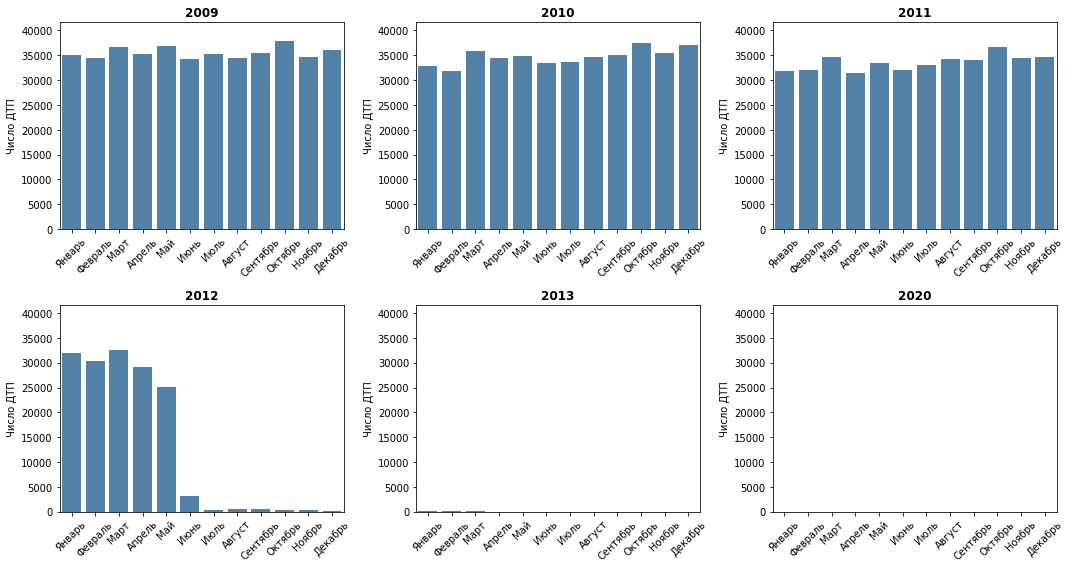

In [15]:
# сетка графиков
n_years = len(years)
cols = 3
rows = (n_years + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

month_names = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель', 5: 'Май', 6: 'Июнь',
    7: 'Июль', 8: 'Август', 9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}

for i, year in enumerate(years):
    plt.subplot(rows, cols, i + 1)
    
    year_data = df[df['year'] == year].copy()
    
    # полный набор месяцев, чтобы явно видеть пропуски
    full_months = pd.DataFrame({'month': range(1, 13)})
    year_data_full = full_months.merge(year_data[['month', 'accident_count']], on='month', how='left')
    year_data_full['accident_count'].fillna(0, inplace=True)
    
    sns.barplot(data=year_data_full, x='month', y='accident_count', color='steelblue')
    plt.title(f'{int(year)}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Число ДТП')
    plt.xticks(ticks=range(12), labels=[month_names[m] for m in range(1, 13)], rotation=45)
    plt.ylim(0, df['accident_count'].max() * 1.1) 

plt.tight_layout()
plt.show()

In [16]:
# суммируем ДТП по месяцам 2009-2011
query_monthly = """
SELECT 
    EXTRACT(MONTH FROM COLLISION_DATE) AS month,
    COUNT(*) AS accident_count
FROM collisions
WHERE COLLISION_DATE IS NOT NULL
  AND EXTRACT(YEAR FROM COLLISION_DATE) IN (2009, 2010, 2011)
GROUP BY month
ORDER BY accident_count DESC;
"""

monthly_data = pd.read_sql(query_monthly, engine)

month_names = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель', 5: 'Май', 6: 'Июнь',
    7: 'Июль', 8: 'Август', 9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}
monthly_data['month_name'] = monthly_data['month'].map(month_names)

print("Рейтинг месяцев по количеству ДТП (2009-2011):")
print(monthly_data[['month_name', 'accident_count']].to_string(index=False))

Рейтинг месяцев по количеству ДТП (2009-2011):
month_name  accident_count
   Октябрь          111933
   Декабрь          107745
      Март          107036
       Май          105148
  Сентябрь          104649
    Ноябрь          104517
    Август          103467
      Июль          101835
    Апрель          101032
    Январь           99880
      Июнь           99531
   Февраль           98373


### Вывод 

Анализ графиков показывает явные признаки неполноты данных в отдельных годах, что критически важно для корректного сезонного анализа:

- 2012 год. Вероятно, данные за второй полугодие 2012 года отсутствуют или не загружены.  
  Использовать 2012 год в анализе нельзя он сильно искажает средние значения.

- 2013 и 2020 годы:  
  - В 2013 году данные присутствуют только за январь-март  
  - В 2020 году только январь и февраль

- 2009 - 2011 годы стабильные и полные.

По анализу 2009-2011:

| Месяц    | Количество ДТП |
|----------|----------------|
| Октябрь  | 111 933        |
| Декабрь  | 107 745        |
| Март     | 107 036        |
| Май      | 105 148        |
| Сентябрь | 104 649        |


Абсолютный максимум - октябрь.

## Подготовка задач для коллег

Для глубокого понимания факторов, влияющих на ДТП с участием каршеринговых автомобилей, предлагаю коллегам выполнить следующие исследования. Каждая задача направлена на выявление потенциальных признаков, которые могут быть использованы в будущей системе оценки риска.

---

1. Влияние погодных условий на серьёзность повреждений  
**Вопрос**: Как погода (`WEATHER_1`) влияет на уровень ущерба (`COLLISION_DAMAGE`)?  
**Обоснование**: Погода -- один из ключевых внешних факторов, который может напрямую влиять на управляемость автомобиля и видимость. Например, дождь или туман могут увеличивать вероятность не только ДТП, но и более серьезных последствий. Анализ этой зависимости поможет определить, стоит ли интегрировать данные о погоде в модель риска.  
**Таблицы**: `collisions` (содержит оба поля).

---

2. Виновность водителей в зависимости от времени суток  
**Вопрос**: Какова доля виновных участников (`AT_FAULT`) среди водителей автомобилей (`PARTY_TYPE`) в разное время суток (`COLLISION_TIME`)?  
**Обоснование**: Ночное время, сумерки или часы пик могут по-разному влиять на концентрацию и реакцию водителя. Если выяснится, что ночью доля виновных значительно выше, это станет важным сигналом для системы: предлагать альтернативные маршруты или усиливать предупреждения в темное время суток.  
**Таблицы**: `collisions` + `parties`.

---

3. Возраст автомобиля и характер повреждений  
**Вопрос**: Связан ли возраст транспортного средства (`VEHICLE_AGE`) с уровнем повреждений (`COLLISION_DAMAGE`)?  
**Обоснование**: Старые автомобили могут иметь изношенные тормоза, подвеску или другие системы безопасности, что повышает риск серьезных аварий. Если связь подтвердится, возраст авто станет обязательным признаком в модели.  
**Таблицы**: `collisions` + `vehicles`.

---

4. Наиболее частые причины ДТП с участием каршеринговых авто  
**Вопрос**: Какие категории нарушений (`PCF_VIOLATION_CATEGORY`) чаще всего встречаются у участников типа «Car»?  
**Обоснование**: Понимание типичных ошибок водителей (например, превышение скорости, неправильный поворот, использование телефона) позволит не только улучшить модель, но и формировать персонализированные рекомендации: «На этом участке часто нарушают правила проезда -- будьте внимательны».  
**Таблицы**: `parties` + `vehicles`.

---

5. Состояние дороги и тип столкновения  
**Вопрос**: Как дорожные условия (`ROAD_CONDITION_1`) влияют на тип аварии (`TYPE_OF_COLLISION`)?  
**Обоснование**: Например, ямы или строительные зоны могут провоцировать боковые удары или столкновения с препятствиями. Если удастся выявить устойчивые паттерны, система сможет предупреждать водителя заранее.  
**Таблицы**: `collisions` содержит оба поля, но для точности можно уточнить через `parties`, чтобы убедиться, что речь идет именно об автомобилях.

---

6. Использование телефона и виновность  
**Вопрос**: Существует ли статистическая связь между использованием телефона (`CELLPHONE_IN_USE`) и фактом виновности (`AT_FAULT`)?  
**Обоснование**: Отвлечение за рулем — одна из главных причин ДТП. Если данные покажут, что водители, разговаривающие по телефону, чаще становятся виновниками, это станет сильным аргументом в пользу технических решений.  
**Таблицы**: `parties` + `vehicles`.

## Возраст автомобиля и характер повреждений

**Цель:** Оценить действительно ли более старые авто чаще получают серьезные повреждения.

In [17]:
# sql-запрос
query_1 = """
SELECT 
    v.VEHICLE_AGE,
    c.COLLISION_DAMAGE
FROM collisions c
JOIN parties p 
    ON c.case_id = p.case_id
JOIN vehicles v 
    ON p.case_id = v.case_id 
    AND p.party_number = v.party_number
WHERE 
    p.PARTY_TYPE = 'car'               -- только автомобили
    AND c.COLLISION_DAMAGE IS NOT NULL
    AND v.VEHICLE_AGE IS NOT NULL;
"""
df_1 = pd.read_sql(query_1, engine)
df_1.head(10)

,vehicle_age,collision_damage
0,17,small damage
1,3,middle damage
2,3,scratch
3,0,middle damage
4,7,scratch
5,4,scratch
6,6,scratch
7,4,scratch
8,4,middle damage
9,3,middle damage


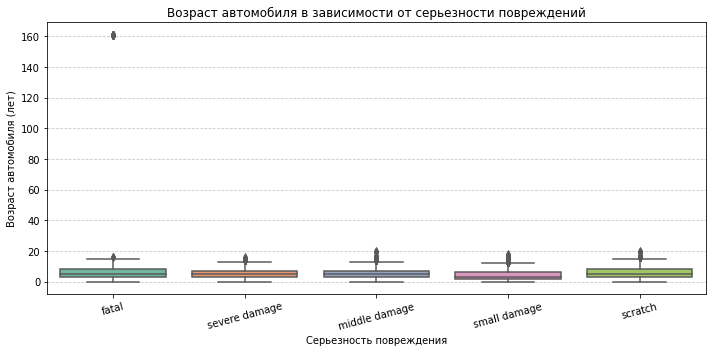

In [18]:
# подготовка данных
df_1['VEHICLE_AGE'] = pd.to_numeric(df_1['vehicle_age'], errors='coerce')
df_1 = df_1.dropna(subset=['VEHICLE_AGE'])

# определим порядок категорий по убыванию серьезности
damage_order = ['fatal', 'severe damage', 'middle damage', 'small damage', 'scratch']
df_1_filtered = df_1[df_1['collision_damage'].isin(damage_order)]

# график
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_1_filtered,
    x='collision_damage',
    y='VEHICLE_AGE',
    order=damage_order,
    palette='Set2'
)
plt.title('Возраст автомобиля в зависимости от серьезности повреждений')
plt.xlabel('Серьезность повреждения')
plt.ylabel('Возраст автомобиля (лет)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Нашли выброс: автомобиль, которому 160 лет, скорее всего это аномалия или ошибка. Посмотрим на данные без этого выброса.

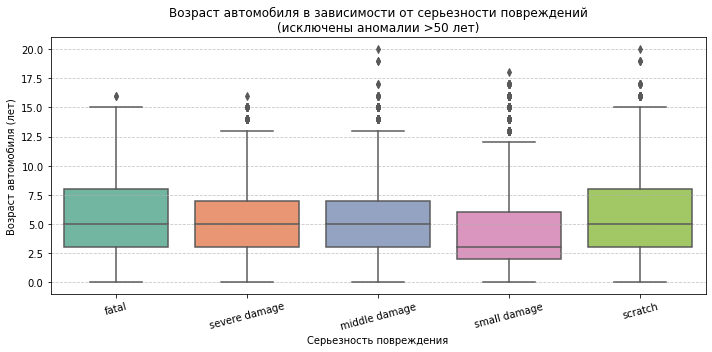

In [19]:
df_1_clean = df_1[df_1['vehicle_age'] <= 50].copy()

# преобразуем типы и фильтруем категории
df_1_clean['VEHICLE_AGE'] = pd.to_numeric(df_1_clean['vehicle_age'], errors='coerce')
df_1_clean = df_1_clean.dropna(subset=['VEHICLE_AGE'])

# задаем порядок категорий по убыванию серьезности
damage_order = ['fatal', 'severe damage', 'middle damage', 'small damage', 'scratch']
df_1_filtered = df_1_clean[df_1_clean['collision_damage'].isin(damage_order)]

# график без аномалий
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_1_filtered,
    x='collision_damage',
    y='VEHICLE_AGE',
    order=damage_order,
    palette='Set2'
)
plt.title('Возраст автомобиля в зависимости от серьезности повреждений\n(исключены аномалии >50 лет)')
plt.xlabel('Серьезность повреждения')
plt.ylabel('Возраст автомобиля (лет)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
median_age_by_damage = df_1_filtered.groupby('collision_damage')['VEHICLE_AGE'].median()
print("Медианный возраст автомобиля по уровню повреждений:")
for dmg in damage_order:
    if dmg in median_age_by_damage:
        print(f"  {dmg}: {median_age_by_damage[dmg]:.1f} лет")

Медианный возраст автомобиля по уровню повреждений:
  fatal: 5.0 лет
  severe damage: 5.0 лет
  middle damage: 5.0 лет
  small damage: 3.0 лет
  scratch: 5.0 лет


### Вывод

Медианный возраст автомобилей, участвовавших в ДТП с разной степенью повреждений, практически не отличается:
- Fatal: 5 лет
- Severe damage: 5 лет
- Middle damage: 5 лет
- Small damage: 3 лет
- scratch: 5 лет

Распределения почти идентичны — возраст автомобиля не является значимым предиктором для уровня повреждений.

Незначительное снижение медианы для `small damage` (до 3 лет) может указывать на то, что молодые авто чаще участвуют в мелких столкновениях — возможно.

**Итог**:
Возраст автомобиля не влияет на вероятность получения серьёзных повреждений.  
Следовательно, при построении модели прогнозирования риска ДТП возраст можно использовать как вспомогательный признак, но не основной.

## Использование телефона и виновность

**Цель:** Проверить, правда ли, что отвлечение на телефон за рулем повышает вероятность стать виновником ДТП.

In [21]:
# sql-запрос
query_2 = """
SELECT 
    p.cellphone_in_use,
    p.at_fault
FROM parties p
JOIN vehicles v 
    ON p.case_id = v.case_id 
    AND p.party_number = v.party_number
WHERE 
    p.party_type = 'car'
    AND p.cellphone_in_use IS NOT NULL;
"""
df_2 = pd.read_sql(query_2, engine)
df_2.head(10)

,cellphone_in_use,at_fault
0,0,0
1,0,0
2,0,0
3,0,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,1


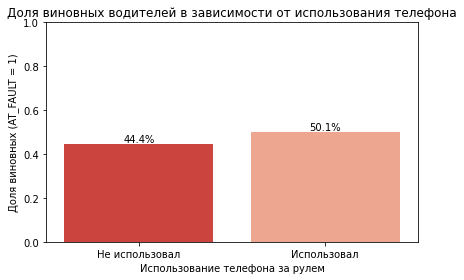

In [22]:
# агрегация
summary = df_2.groupby('cellphone_in_use').agg(
    total=('at_fault', 'count'),
    at_fault=('at_fault', 'sum')
).reset_index()

# добавляем метки для графика
summary['fault_rate'] = summary['at_fault'] / summary['total']
summary['usage_label'] = summary['cellphone_in_use'].map({0: 'Не использовал', 1: 'Использовал'})

# график
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x='usage_label', y='fault_rate', palette='Reds_r')
plt.title('Доля виновных водителей в зависимости от использования телефона')
plt.xlabel('Использование телефона за рулем')
plt.ylabel('Доля виновных (AT_FAULT = 1)')
plt.ylim(0, 1)
for i, row in summary.iterrows():
    plt.text(i, row['fault_rate'] + 0.01, f"{row['fault_rate']:.1%}", ha='center')
plt.tight_layout()
plt.show()

### Вывод

На основе анализа:
- Среди водителей, не использовавших телефон, доля виновных составляет -- 44.4%.
- Среди водителей, использовавших телефон, доля виновных -- 50.1%.
- Разница составляет -- 5.7%.

- Использование телефона за рулем статистически связано с повышенной вероятностью стать виновником ДТП.
- Признак `cellphone_in_use` следует обязательно включить в модель прогнозирования риска.

**Итого**:  
Фактор отвлечения внимания подтвержден данными и может стать одним из ключевых сигналов в будущей системе оценки риска.

# Создание модели для оценки водительского риска

## Формирование обучающего датасета

**Требования в ТЗ:**
- тип виновника -- автомобиль
- только значимые повреждения (без царапин)
- данные только за 2012 год
- целевая переменная: AT_FAULT (0/1)
- подготовка исходной таблицы с помощью sql-запроса
- обязательное условие -- учесть фактор возраста автомобиля.

Цель нашей модели - оценить вероятность того, что водитель автомобиля станет виновником ДТП при заданных условиях (маршрут, время суток, погода и т.д.). Это напрямую связано с задачей каршеринговой компании - предупредить пользователя до начала поездки, если риск повышен.

Исходя из этого, мы отбираем признаки по трем критериям:
1. Доступность до начала движения (или возможность получения из контекста маршрута/прогноза).
2. Статистическая связь с виновностью в ДТП (целевая переменная `at_fault`).
3. Наличие в таблицах: `collisions`, `parties`, `vehicles`.

**Важное уточнение**: целевая переменная `at_fault` отражает виновность при уже произошедшем ДТП, а не сам факт ДТП. Это ограничение исторических данных. Для реальной системы оценки риска маршрута потребуется дообучение на данных, включающих поездки без ДТП.

---

**Признаки из таблицы `parties`**

| Признак                | Обоснование                                                                 | Доступность до поездки |
|------------------------|------------------------------------------------------------------------------|------------------------|
| `party_type`           | Фильтрация только по типу «автомобиль» (`'1'`) - обязательное условие ТЗ    | Да |
| `at_fault`             | **Целевая переменная (0/1)** - был ли участник-автомобиль виновником ДТП    | -                      |
| `party_sobriety`       | Уровень трезвости - ключевой фактор аварийности                             | Нет (требует алкотестера + камеры) |
| `party_drug_physical`  | Влияние лекарств/физического состояния на управление ТС                     | Нет (требует биометрических датчиков) |
| `cellphone_in_use`     | Использование телефона - фактор отвлечения внимания                         | Нет (требует камеры для детекции) |

Признаки состояния водителя (`party_sobriety`, `cellphone_in_use`, `party_drug_physical`) критически важны для точности модели, но в текущих данных недоступны до начала поездки. Их использование в продакшене потребует оборудования авто датчиками.

---

**Признаки из таблицы `vehicles`**

| Признак                | Обоснование                                                                 | Доступность до поездки |
|------------------------|------------------------------------------------------------------------------|------------------------|
| `vehicle_age`          | **Обязательный признак по ТЗ** - возраст влияет на надежность систем безопасности | Да |
| `vehicle_type`         | Тип кузова (SEDAN, HATCHBACK и др.) - влияет на маневренность и устойчивость | Да |
| `vehicle_transmission` | Тип КПП (автомат/механика) - может влиять на контроль в стрессовых ситуациях | Да |

---

**Признаки из таблицы `collisions`**

| Признак                | Обоснование                                                                 | Доступность до поездки |
|------------------------|------------------------------------------------------------------------------|------------------------|
| `EXTRACT(MONTH FROM collision_date)` | Сезонность аварийности (пик - март по анализу Шага 3)                     | Да (известно время бронирования) |
| `weather_1`            | Погода - влияет на видимость и сцепление с дорогой                          | Да (прогноз погоды для маршрута) |
| `road_surface`         | Состояние покрытия (сухое/мокрое/скользкое) - критично для тормозного пути  | Да (исторические данные + прогноз) |
| `lighting`             | Освещенность - влияет на реакцию водителя                                   | Да (время суток + тип дороги) |
| `intersection`         | Перекрестки - зоны повышенного риска                                        | Да (известны из маршрута) |
| `road_condition_1`     | Доп. условия дороги (ямы, стройка) - отражают специфику маршрута            | Да (карты + исторические данные) |
| `county_location`      | Географический фактор - разные районы имеют разную аварийность              | Да (известен из маршрута) |
| `location_type`        | Тип дороги (шоссе, перекресток, рампа) - влияет на характер движения и риски | Да (известен из маршрута) |
| `direction`            | Направление движения - может коррелировать с интенсивностью потока и риском | Да (известно из маршрута) |
| `distance`             | Расстояние от главной дороги (метры) - отражает специфику локации           | Да (известно из маршрута) |

---

**Итог**

Мы формируем датасет на уровне участника-автомобиля в ДТП с повреждениями (исключая царапины), где каждая строка описывает:
1. характеристики автомобиля (известны заранее)
2. внешние условия (доступны из маршрута и прогноза)

Это позволяет выявить ключевые факторы виновности и заложить основу для системы персонализированных предупреждений. Для перехода от "предсказания виновности при ДТП" к "оценке риска ДТП по маршруту" потребуется:
- сбор данных о поездках без ДТП
- интеграция датчиков для мониторинга состояния водителя
- учет динамических факторов (пробки, текущая погода)

In [23]:
# формирование обучающего датасета
query_model = """
SELECT 
    -- Целевая переменная (из parties)
    p.AT_FAULT,
    
    -- Признаки водителя (parties)
    p.CELLPHONE_IN_USE,
    
    -- Признаки автомобиля (vehicles)
    v.VEHICLE_AGE,
    v.VEHICLE_TYPE,
    v.VEHICLE_TRANSMISSION,
    
    -- Контекст ДТП (collisions)
    c.WEATHER_1,
    c.ROAD_SURFACE,
    c.LIGHTING,
    c.INTERSECTION,
    c.ROAD_CONDITION_1,
    c.LOCATION_TYPE,
    c.DIRECTION,
    c.DISTANCE,
    c.COUNTY_LOCATION

FROM collisions c
-- Связываем с участниками-автомобилями
INNER JOIN parties p 
    ON c.case_id = p.case_id
    AND p.party_type = 'car'
    
-- Обязательно подключаем возраст авто
INNER JOIN vehicles v 
    ON p.case_id = v.case_id 
    AND p.party_number = v.party_number

WHERE 
    -- Только 2012 год
    EXTRACT(YEAR FROM c.collision_date) = 2012
    
    -- Только значимые повреждения (исключаем царапины)
    AND c.collision_damage != 'scratch';
"""

# загружаем данные
df_model = pd.read_sql(query_model, engine)

print(f"Размер датасета: {df_model.shape}")

Размер датасета: (56248, 14)


In [24]:
inspect_df(df_model)

Размер: 56248 строк, 14 столбцов

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   at_fault              56248 non-null  int64  
 1   cellphone_in_use      51777 non-null  float64
 2   vehicle_age           54554 non-null  float64
 3   vehicle_type          56248 non-null  object 
 4   vehicle_transmission  55389 non-null  object 
 5   weather_1             56080 non-null  object 
 6   road_surface          55900 non-null  object 
 7   lighting              56094 non-null  object 
 8   intersection          56073 non-null  float64
 9   road_condition_1      55999 non-null  object 
 10  location_type         25932 non-null  object 
 11  direction             43230 non-null  object 
 12  distance              56248 non-null  float64
 13  county_location       56248 non-null  object 
dtypes: float64(4), int64(1), objec

,at_fault,cellphone_in_use,vehicle_age,vehicle_type,vehicle_transmission,weather_1,road_surface,lighting,intersection,road_condition_1,location_type,direction,distance,county_location
0,1,0.0,3.0,sedan,manual,clear,dry,dark with street lights,0.0,normal,highway,south,1500.0,san diego
1,0,0.0,10.0,sedan,manual,clear,dry,dark with street lights,0.0,normal,None,east,21.0,contra costa
2,0,NaN,3.0,sedan,auto,clear,dry,daylight,0.0,None,None,west,150.0,san bernardino
3,0,0.0,10.0,sedan,auto,clear,dry,daylight,0.0,normal,highway,east,450.0,los angeles
4,0,NaN,8.0,sedan,auto,clear,dry,daylight,1.0,normal,None,None,0.0,los angeles
5,0,0.0,3.0,sedan,auto,clear,dry,daylight,0.0,normal,None,east,38.0,los angeles
6,0,NaN,8.0,sedan,auto,clear,dry,daylight,1.0,normal,None,None,0.0,san diego
7,1,NaN,9.0,sedan,auto,clear,dry,daylight,0.0,normal,None,west,210.0,sacramento
8,0,0.0,11.0,sedan,auto,clear,dry,daylight,0.0,normal,ramp,west,175.0,orange
9,0,0.0,1.0,sedan,auto,cloudy,dry,daylight,1.0,normal,ramp,None,0.0,shasta



Последние 10 строк:


,at_fault,cellphone_in_use,vehicle_age,vehicle_type,vehicle_transmission,weather_1,road_surface,lighting,intersection,road_condition_1,location_type,direction,distance,county_location
56238,1,0.0,3.0,coupe,manual,clear,dry,daylight,0.0,normal,None,east,20.0,sacramento
56239,0,0.0,7.0,coupe,manual,clear,dry,daylight,0.0,normal,None,west,60.0,san bernardino
56240,0,0.0,4.0,coupe,manual,cloudy,dry,daylight,0.0,normal,highway,north,1200.0,san diego
56241,1,0.0,8.0,coupe,auto,cloudy,wet,daylight,0.0,normal,highway,west,2112.0,calaveras
56242,0,NaN,6.0,coupe,manual,raining,wet,daylight,0.0,other,None,east,248.0,san francisco
56243,0,NaN,3.0,coupe,manual,clear,dry,daylight,1.0,normal,None,None,0.0,los angeles
56244,1,0.0,2.0,coupe,manual,cloudy,wet,daylight,0.0,normal,highway,west,5.0,ventura
56245,1,1.0,9.0,coupe,auto,clear,dry,daylight,0.0,normal,None,east,12.0,sacramento
56246,0,0.0,8.0,coupe,manual,clear,dry,daylight,1.0,normal,None,None,0.0,los angeles
56247,1,0.0,3.0,coupe,auto,cloudy,wet,daylight,0.0,normal,highway,south,180.0,los angeles


Датасет сформирован, но:
- `cellphone_in_use` более 75% значений 0, статистически несет значимость, но нужно исследовать
- `vehicle_age` уже видели выброс в 161 год, оценить и, при необходимости, удалить
- нужно будет сменить типы данных
- скорее всего есть дубликаты неявные -- проверить

In [25]:
df_model.duplicated().sum()

6582

In [26]:
print(f"До удаления: {len(df_model)} строк")
df_model = df_model.drop_duplicates().reset_index(drop=True)
print(f"После удаления: {len(df_model)} строк")

До удаления: 56248 строк
После удаления: 49666 строк


Посмотрим на аномальные значения возраста автомобиля

In [27]:
df_model[df_model['vehicle_age'] > 100]

,at_fault,cellphone_in_use,vehicle_age,vehicle_type,vehicle_transmission,weather_1,road_surface,lighting,intersection,road_condition_1,location_type,direction,distance,county_location
21509,1,0.0,161.0,sedan,manual,clear,dry,daylight,0.0,normal,None,north,449.0,los angeles
24427,0,0.0,161.0,sedan,manual,clear,dry,dusk or dawn,1.0,normal,ramp,None,0.0,los angeles


Их немного, удалим, а вместе с ним и пустые значения в этом столбце, т.к. мы не знаем чем их заполнять (медианой или модой может ввести в заблуждение модель).

In [28]:
print(f'До удаления {df_model.shape}')
df_model = df_model[df_model['vehicle_age'] < 100]
print(f'После удаления {df_model.shape}')

До удаления (49666, 14)
После удаления (48178, 14)


Обработаем данные в столбце `party_drug_physical`:
- значение "G" заменим на понятное
- пустые значения заполним "Unknown"

In [29]:
df_model['cellphone_in_use'] = df_model['cellphone_in_use'].fillna(0)
df_model['cellphone_in_use'].value_counts()

0.0    47177
1.0     1001
Name: cellphone_in_use, dtype: int64

In [30]:
df_model['vehicle_transmission'] = df_model['vehicle_transmission'].fillna('Unknown')
df_model['vehicle_transmission'].value_counts()

manual     25362
auto       22249
Unknown      567
Name: vehicle_transmission, dtype: int64

In [31]:
df_model['weather_1'] = df_model['weather_1'].fillna('clear')
df_model['weather_1'].value_counts()

clear      37843
cloudy      7880
raining     2088
fog          171
snowing      153
other         32
wind          11
Name: weather_1, dtype: int64

In [32]:
df_model['road_surface'] = df_model['road_surface'].fillna('dry')
df_model['lighting'] = df_model['lighting'].fillna('daylight')
df_model['intersection'] = df_model['intersection'].fillna(0)
df_model['road_condition_1'] = df_model['road_condition_1'].fillna('normal')
df_model['location_type'] = df_model['location_type'].fillna('normal_road')
df_model['direction'] = df_model['direction'].fillna('Unknown')

In [33]:
df_model.isna().sum()

at_fault                0
cellphone_in_use        0
vehicle_age             0
vehicle_type            0
vehicle_transmission    0
weather_1               0
road_surface            0
lighting                0
intersection            0
road_condition_1        0
location_type           0
direction               0
distance                0
county_location         0
dtype: int64

## Исследование данных

### Целевая переменная `at_fault`

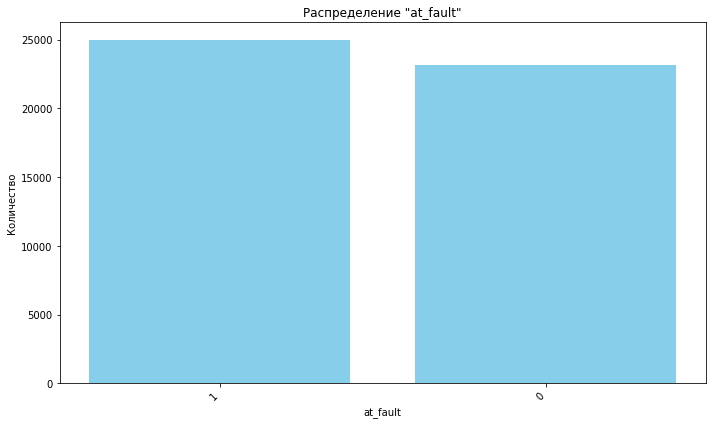

In [34]:
plot_feature_for_classification(df_model, 'at_fault', target=None, figsize=(10, 6))

In [35]:
print("Распределение целевой переменной:")
print(df_model['at_fault'].value_counts(normalize=True))

Распределение целевой переменной:
1    0.518951
0    0.481049
Name: at_fault, dtype: float64


**Вывод:**

Выборка почти сбалансирована (51% виновных vs 49% невиновных).

### `cellphone_in_use`

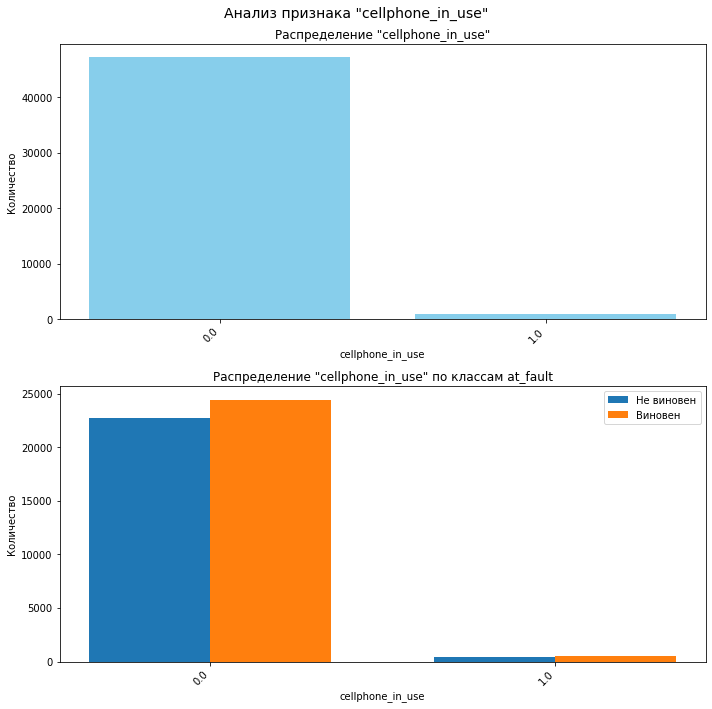

In [36]:
plot_feature_for_classification(df_model, 'cellphone_in_use')

**Вывод:**

Большинство водителей не использовали телефон во время вождения в 2012 году, видим значительные улучшения по сравнению со всей базой, но виновность выше.

### `vehicle_age`

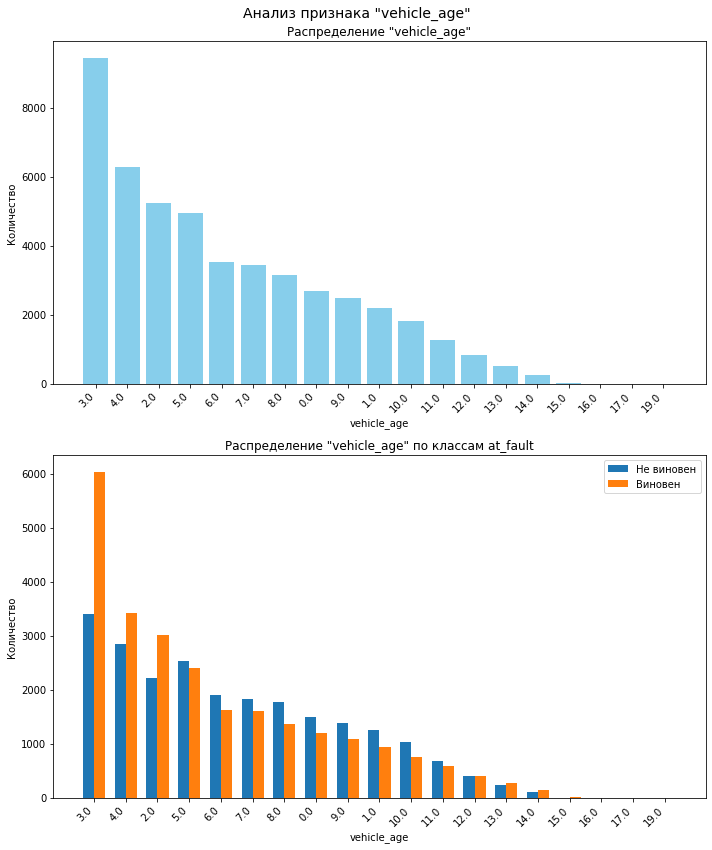

In [37]:
plot_feature_for_classification(df_model, 'vehicle_age', figsize=(10, 12))

**Вывод:**

- Большинство автомобилей в выборке — молодые (до 5 лет).  
    Пик распределения приходится на возраст 3 года - это типично для коммерческого автопарка, где машины обновляются каждые 3-5 лет.
- С увеличением возраста автомобиля частота ДТП снижается, но это не означает, что старые авто безопаснее (скорее всего) их меньше в парке.
- Среди водителей, управлявших молодыми автомобилями (до 5 лет), доля виновных выше, чем среди тех, кто ездил на более старых машинах.
- Для автомобилей возрастом 2-4 года - оранжевый столбец (виновные) выше синего, риск виновности выше.
- Для машин старше 5 лет - риск близок к среднему.
- Для машин старше 11 лет риск виновности снова стал выше.

Предположу:  
Владельцы новых машин могут быть более самоуверенными и рисковать больше.

### `vehicle_type`

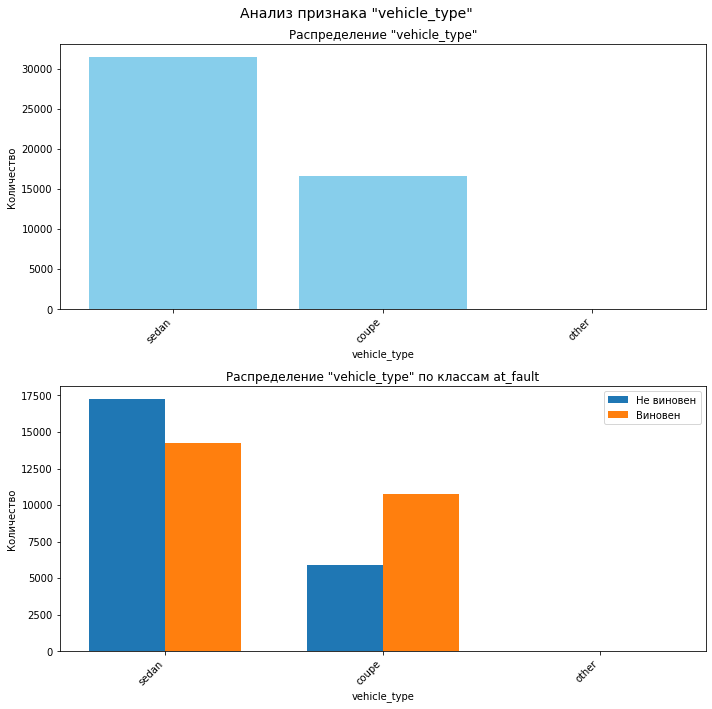

In [38]:
plot_feature_for_classification(df_model, 'vehicle_type')

**Вывод:**

- Большинство автомобилей в выборке: седаны.
- Купе вторая по популярности категория.
- Категория "other" почти отсутствует.
- Среди владельцев купе доля виновных выше, чем среди владельцев седанов.

Тип кузова влияет на поведение водителя:  
Владельцы купе чаще становятся виновниками ДТП, чем владельцы седанов.

Предположу:  
Купе - часто покупаются молодыми водителями, которые склонны к рискованному вождению.

### `vehicle_transmission`

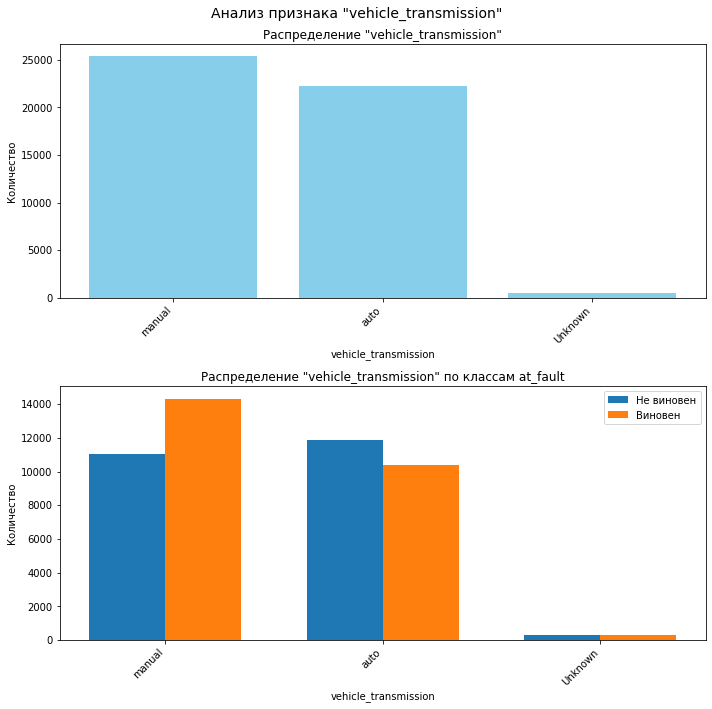

In [39]:
plot_feature_for_classification(df_model, 'vehicle_transmission')

**Вывод:**

- В выборке почти поровну автомобилей с механической и автоматической коробками передач.
- Однако водители на механике чаще оказываются виновниками ДТП.
- У владельцев автоматической ситуация обратная - невиновных больше, чем виновных.

### `weather_1`

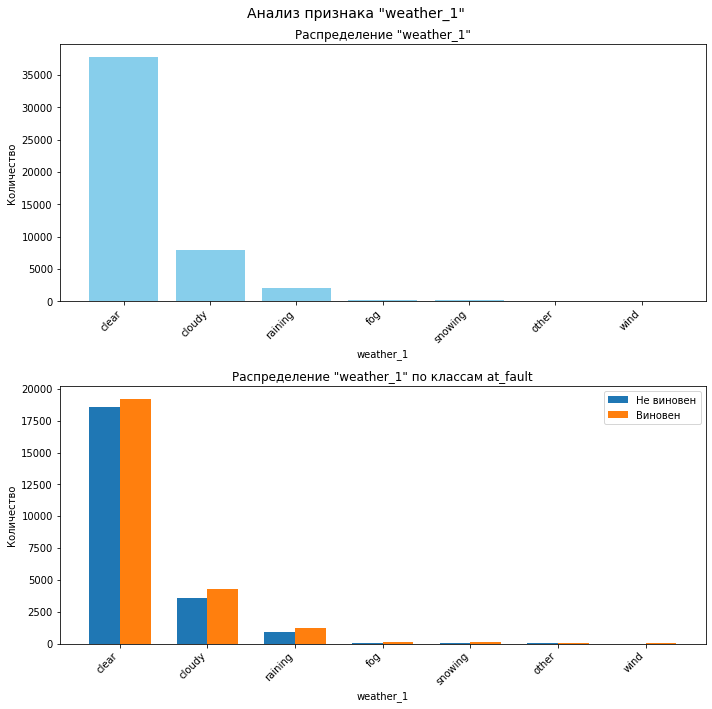

In [40]:
plot_feature_for_classification(df_model, 'weather_1')

**Вывод:**

- Подавляющее большинство ДТП происходит в ясную погоду (clear).
- В пасмурную и дождливую погоду количество ДТП резко снижается, но доля виновных среди них выше, вероятно, из-за ухудшения сцепления, видимости и неподготовленности водителей.

Погода влияет на риск ДТП.

### `road_surface`

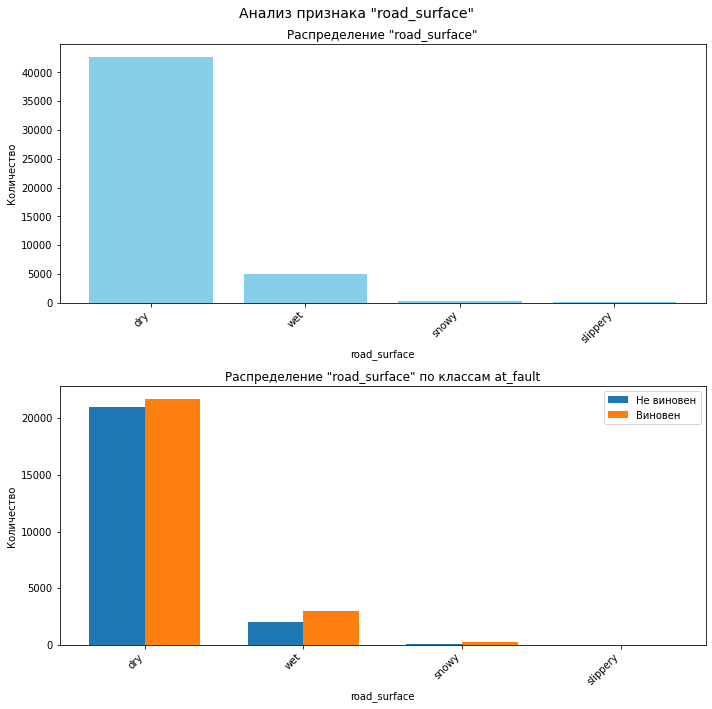

In [41]:
plot_feature_for_classification(df_model, 'road_surface')

**Вывод:**

- Подавляющее большинство ДТП происходит на сухой дороге.
- Однако при этом доля виновных водителей на мокрой и скользкой дороге выше, чем на сухой — несмотря на меньшее количество аварий.

Состояние дороги влияет на риск.

### `lighting`

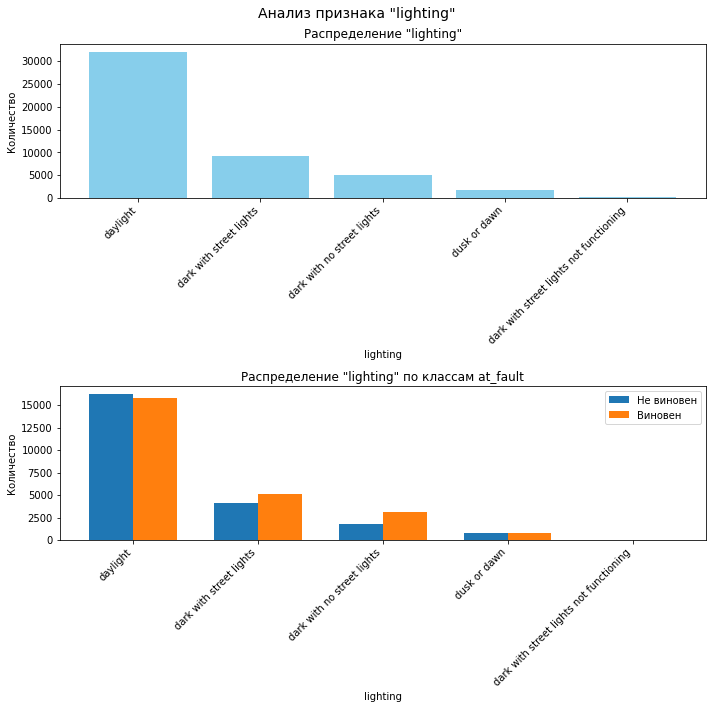

In [42]:
plot_feature_for_classification(df_model, 'lighting')

**Вывод:**

- Подавляющее большинство ДТП происходит днем. Это логично: днем активность на дорогах максимальна.
- Однако при этом доля виновных водителей в темное время суток выше, особенно в условиях «dark with no street lights».
- В сумерках/рассвете и ночью с исправными фонарями риск также выше, чем днём — но ниже, чем в полной темноте.

Освещённость влияет на риск:  
Хотя днем аварий больше по числу, наиболее опасным для водителя является отсутствие освещения. Именно в этих условиях он чаще допускает ошибки, приводящие к ДТП.

### `intersection`

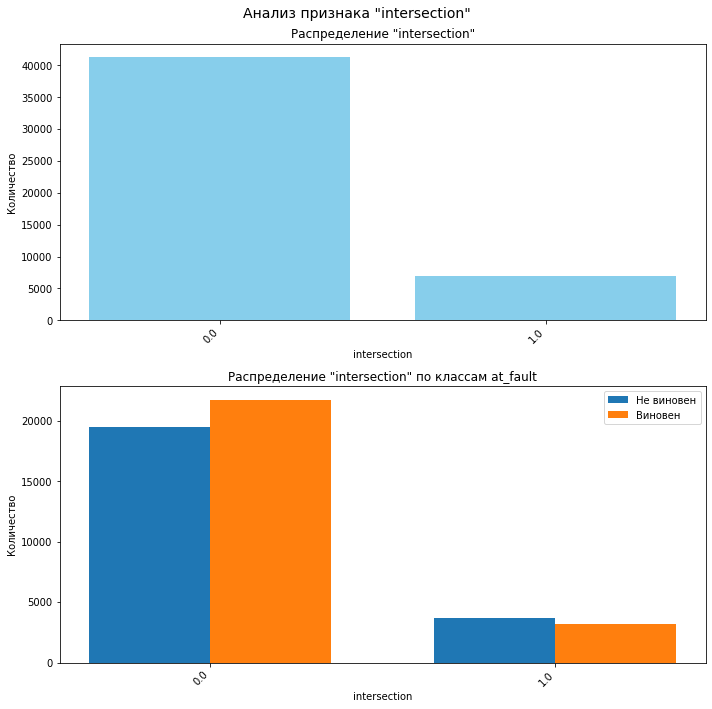

In [43]:
plot_feature_for_classification(df_model, 'intersection')

**Вывод:**

- Подавляющее большинство ДТП происходит не на перекрестках и доля виновных больше.
- На перекрестках виновных почти столько же, сколько невиновных.

Перекрестки - не самая рискованная зона для водителя.

### `road_condition_1`

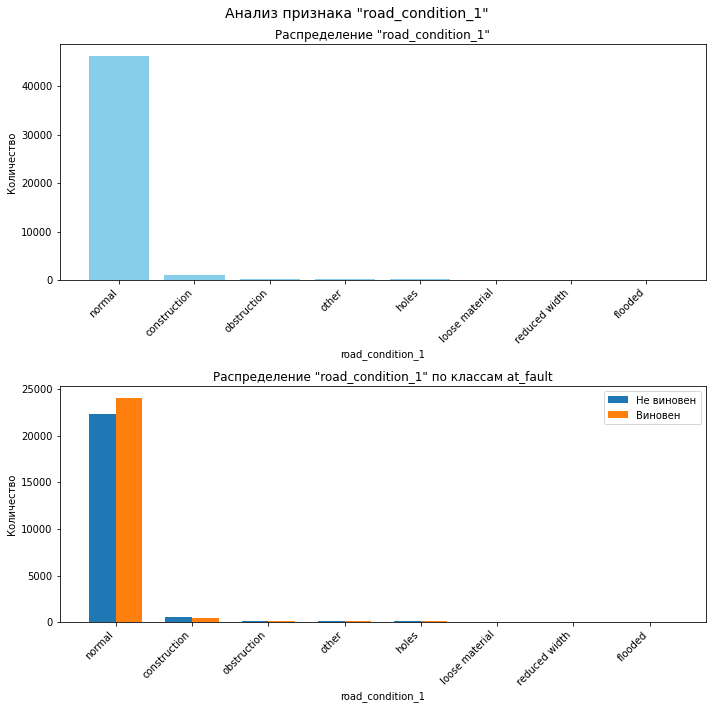

In [44]:
plot_feature_for_classification(df_model, 'road_condition_1')

**Вывод:**

- Подавляющее большинство ДТП происходит при нормальном состоянии дороги (normal).
- Все остальные состояния (строительство, препятствия, ямы, затопление и т.д.) встречаются крайне редко.
- При этом на нормальной дороге доля виновных водителей почти равна доле невиновных, что говорит о высокой доле случайных или взаимных ситуаций.
- В нестандартных условиях (например, construction, obstruction) виновных значительно меньше - но, вероятно, это связано с малым числом таких случаев.

Состояние дороги — не главный фактор риска.

### `location_type`

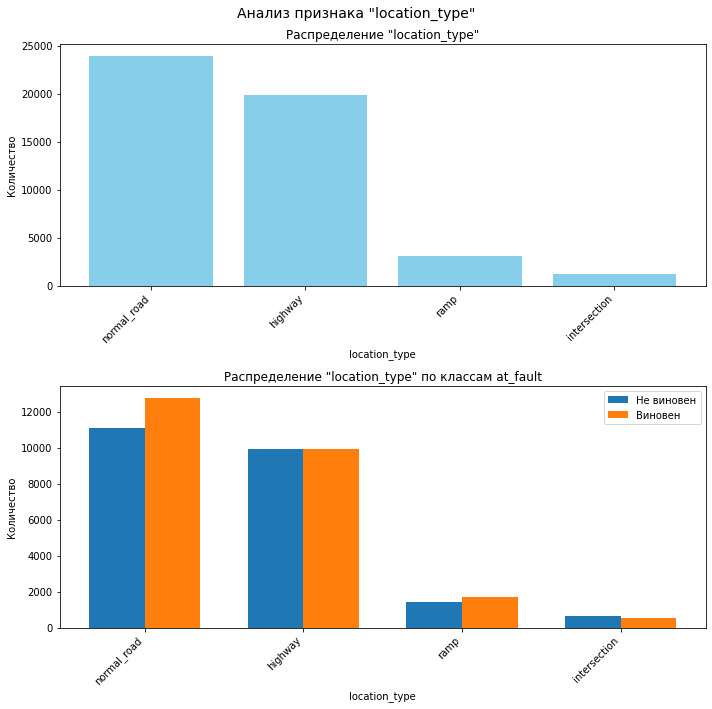

In [45]:
plot_feature_for_classification(df_model, 'location_type')

**Вывод:**

- Подавляющее большинство ДТП происходит на обычной дороге и на шоссе.
- Нампа и перекресток - мало данных.
- На графике видно, что на обычной дороге и на рампе больший риск быть виновным в ДТП.

### `direction`

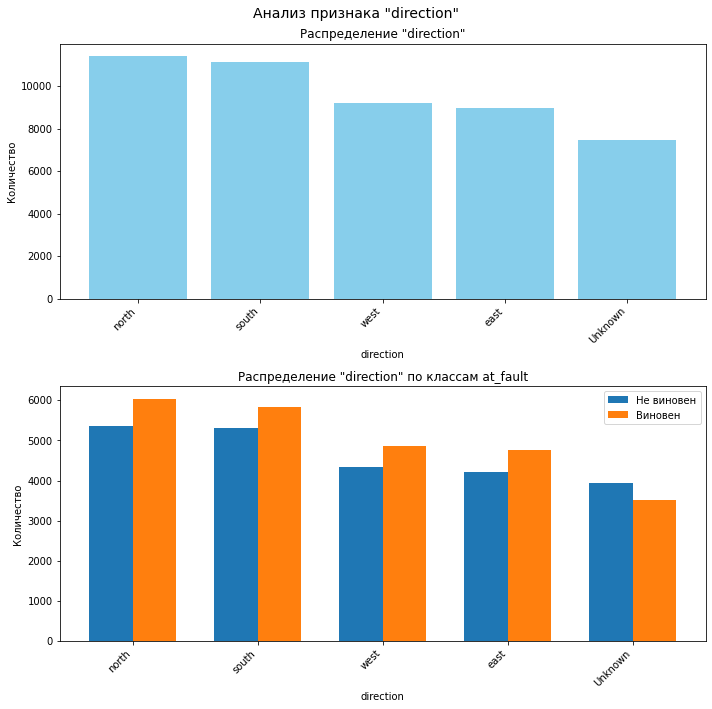

In [46]:
plot_feature_for_classification(df_model, 'direction')

**Вывод:**

Направление движения слабо влияет на вероятность вины, но движение на север и юг связано с наибольшим числом ДТП.

### `distance`

Для начала переведем метры в километры.

In [47]:
df_model['distance'].sort_values()

18169          0.0
22992          0.0
46998          0.0
7042           0.0
35328          0.0
           ...    
41841      79200.0
32592      81312.0
28486     124080.0
4505      171600.0
26078    1584000.0
Name: distance, Length: 48178, dtype: float64

In [48]:
df_model['distance'] = df_model['distance'] / 1000
df_model = df_model[df_model['distance'] < 1000] 

In [49]:
df_model['distance'].sort_values()

30903      0.000
7153       0.000
34111      0.000
15047      0.000
15046      0.000
          ...   
29843     79.200
41841     79.200
32592     81.312
28486    124.080
4505     171.600
Name: distance, Length: 48177, dtype: float64

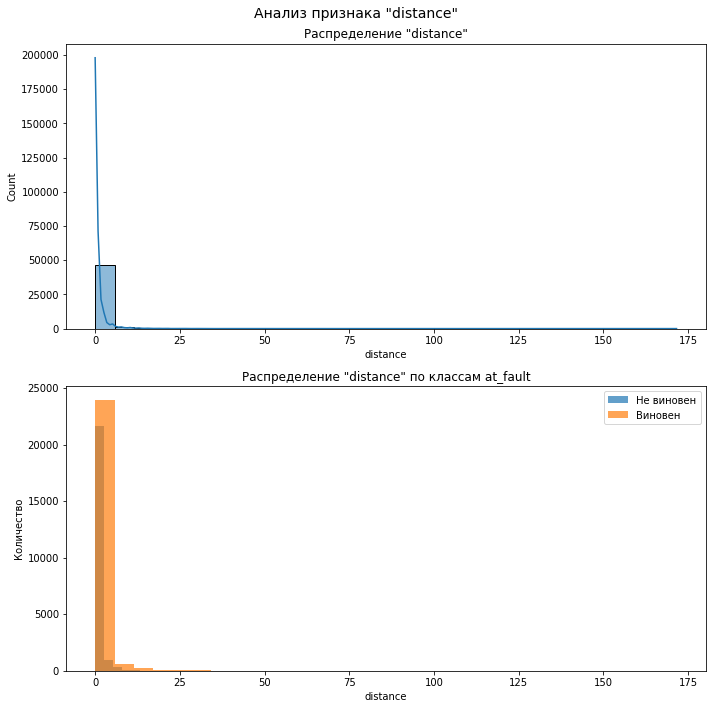

In [50]:
plot_feature_for_classification(df_model, 'distance')

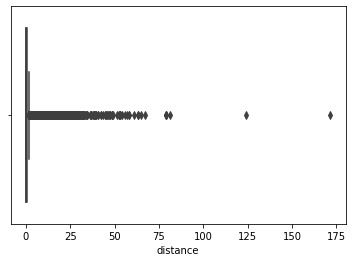

In [51]:
sns.boxplot(x=df_model['distance'])
plt.show()

**Вывод:**

Признак `distance` не является значимым предиктором для `at_fault`. Убираем.

### `county_location`

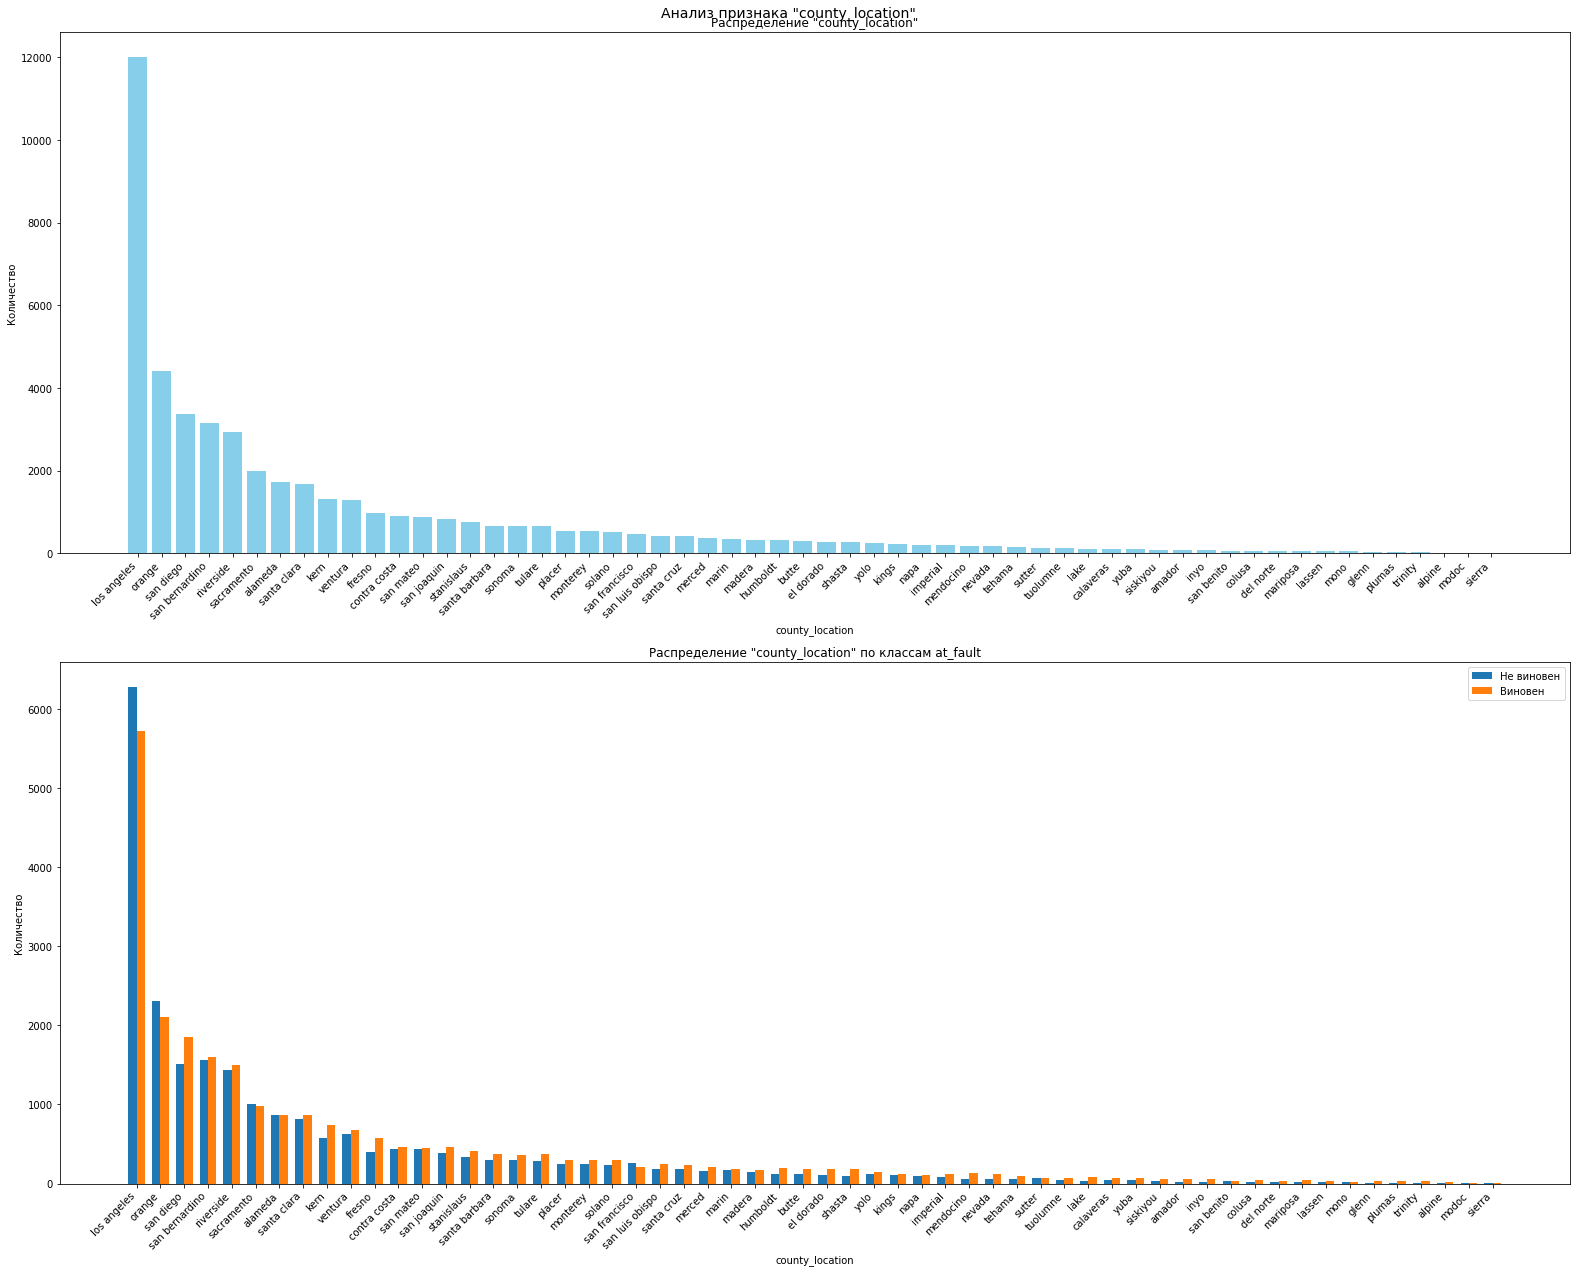

In [52]:
plot_feature_for_classification(df_model, 'county_location', figsize=(22, 18))

In [53]:
crosstab = pd.crosstab(
    df_model['county_location'],
    df_model['at_fault'],
    margins=True  # добавляет строку "All" и столбец "All"
)

# Переименовываем столбцы для ясности
crosstab.columns = ['не_виновен', 'виновен', 'всего']
crosstab.index.name = 'Регионы, где было ДТП'

# Добавляем столбец "доля_виновности" (кроме строки "All")
crosstab['доля_виновности'] = crosstab['виновен'] / crosstab['всего']

# Сортируем по убыванию общего количества (кроме строки "All")
crosstab_sorted = crosstab.iloc[:-1].sort_values('всего', ascending=False)

# Добавляем строку "All" в конец
result = pd.concat([crosstab_sorted, crosstab.loc[['All']]])

# Форматируем долю в процентах для лучшей читаемости (опционально)
result['доля_виновности'] = result['доля_виновности'].map('{:.2%}'.format)

result

,не_виновен,виновен,всего,доля_виновности
"Регионы, где было ДТП",,,,
los angeles,6279,5728,12007,47.71%
orange,2305,2103,4408,47.71%
san diego,1516,1860,3376,55.09%
san bernardino,1564,1600,3164,50.57%
riverside,1431,1502,2933,51.21%
sacramento,1007,986,1993,49.47%
alameda,864,870,1734,50.17%
santa clara,817,872,1689,51.63%
kern,573,735,1308,56.19%


**Вывод:**

- Большинство ДТП происходит в Los Angeles, но доля виновных водителей там всего 47%.
- В крупных мегаполисах (Orange, San Diego, Sacramento) доля виновности близка к средней.
- Однако в менее населенных округах доля виновных водителей резко возрастает.
- Это может быть связано с:
  - более высокими скоростями на загородных дорогах,
  - отсутствием светофоров и разметки.

География влияет на риск виновности:  
Хотя крупные города генерируют больше ДТП по числу, водители в малых округах чаще становятся виновниками, вероятно, из-за особенностей дорожной инфраструктуры и стиля вождения.

## Корреляционный анализ

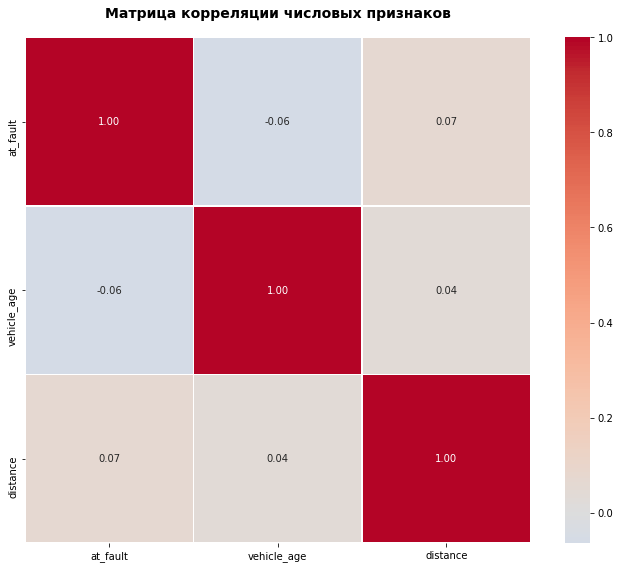

In [54]:
# Подготовка данных для корреляционного анализа
df_corr = df_model.copy()

# Преобразуем бинарные категориальные признаки в числовые для корреляции
df_corr['cellphone_in_use'] = df_corr['cellphone_in_use'].astype(int)
df_corr['intersection'] = df_corr['intersection'].astype(int)

# Числовые признаки + целевая переменная
numeric_cols = ['at_fault', 'vehicle_age', 'distance']
corr_matrix = df_corr[numeric_cols].corr()

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляции числовых признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Вывод:**

Матрица показывает, что никакой значимой линейной связи между числовыми признаками и виновностью (at_fault) нет. Числовые признаки сами по себе не объясняют виновность, скорее всего ключевые факторы риска скрыты в категориальных переменных.

### Вывод

- Выборка почти сбалансирована (51% виновных vs 49% невиновных).

---
1. Характеристики автомобиля имеют неочевидное влияние
- Возраст авто (vehicle_age):
    - Пик риска приходится на автомобили 2–4 лет (возможно, из-за самоуверенности водителей на "новых" машинах)
    - Повторный рост риска у авто старше 11 лет
- Тип кузова (vehicle_type):
    - Владельцы купе чаще становятся виновниками ДТП по сравнению с владельцами седанов

Каршеринг может учитывать возраст и тип авто при распределении парка.

2. Внешние условия: 
- Большинство ДТП происходит в "безопасных" условиях (ясная погода, сухая дорога, дневное время), но доля виновных выше в неблагоприятных условиях:
    - Мокрая/скользкая дорога
    - Темное время суток (особенно без уличного освещения)
    - Плохая погода (дождь, снег)

Система должна учитывать не только статистику ДТП, но и условную вероятность виновности при конкретных внешних условиях маршрута.

3. Географический фактор
В крупных городах больше ДТП по числу, но выше доля виновных в малонаселенных округах - вероятно, из-за более высоких скоростей и отсутствия инфраструктуры.

Для загородных маршрутов система должна применять повышенный порог риска.

4. Матрица корреляций показывает, что никакой значимой линейной связи между числовыми признаками и виновностью (at_fault) нет. Числовые признаки сами по себе не объясняют виновность, скорее всего ключевые факторы риска скрыты в категориальных переменных.

---

**Итог**  
Анализ подтверждает принципиальную возможность создания системы оценки водительского риска. Однако ключевое ограничение текущих данных - отсутствие информации о состоянии водителя до начала поездки. Критически необходимо:
1. Оборудовать автомобили датчиками для оценки трезвости, усталости водителя и пользование телефоном
2. Собрать данные о поездках без ДТП для формирования полноценной задачи классификации
3. Интегрировать внешние источники (прогноз погоды, дорожная обстановка) для оценки условий маршрута  
Без этих шагов система будет ограничена анализом исторических ДТП и не сможет эффективно предупреждать водителей до начала движения.

## Подготовка данных

In [55]:
# разделяем признаки
X = df_model.drop(columns=['at_fault', 'distance'], errors='ignore')
y = df_model['at_fault']

# определяем типы столбцов
categorical_features = ['cellphone_in_use', 'intersection', 'vehicle_type',
                        'vehicle_transmission', 'weather_1', 'road_surface', 'lighting',
                        'road_condition_1', 'location_type', 'direction', 'county_location']
numerical_features = ['vehicle_age']

print("Числовые признаки:", numerical_features)
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['vehicle_age']
Категориальные признаки: ['cellphone_in_use', 'intersection', 'vehicle_type', 'vehicle_transmission', 'weather_1', 'road_surface', 'lighting', 'road_condition_1', 'location_type', 'direction', 'county_location']


In [56]:
# разделение на train/test (сохраняем баланс классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
# создаем трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='error'), categorical_features)
    ]
)

# применяем к обучающей и тестовой выборкам
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Форма обработанных данных:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

Форма обработанных данных:
X_train_processed: (38541, 91)
X_test_processed: (9636, 91)


## Обучение моделей

Для выбора и сравнения моделей будет использована кросс-валидированная ROC-AUC (CV_ROC-AUC), так как она:
- Обеспечивает устойчивую оценку качества. Кросс-валидация усредняет результат по нескольким разбиениям данных, что снижает риск переобучения
- Сохраняет все преимущества ROC-AUC
    - Не зависит от порога классификации
    - Устойчива к дисбалансу классов (сейчас он небольшой, но чаще всего данные несбалансированы)

In [58]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
}

In [59]:
lr_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'saga']
}

lr_result = evaluate_model_full(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    X_train_processed, y_train,
    "Logistic Regression"
)

Обучение модели: Logistic Regression
Лучшие параметры: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Кросс-валидационный ROC-AUC: 0.6436


In [60]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'random_state': [42]
}

rf_result = evaluate_model_full(
    RandomForestClassifier(),
    rf_params,
    X_train_processed, y_train,
    "Random Forest"
)

Обучение модели: Random Forest
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200, 'random_state': 42}
Кросс-валидационный ROC-AUC: 0.6544


In [61]:
xgb_params = {
    'n_estimators': [200],
    'max_depth': [3, 6],
    'learning_rate': [0.05],
    'subsample': [0.8, 1.0],
    'random_state': [42]
}

xgb_result = evaluate_model_full(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    xgb_params,
    X_train_processed, y_train,
    "XGBoost"
)

Обучение модели: XGBoost
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}
Кросс-валидационный ROC-AUC: 0.6638


In [70]:
results = [lr_result, rf_result, xgb_result]

comparison = pd.DataFrame([
    {
        'Model': r['model'].__class__.__name__,
        'CV_ROC-AUC': r['cv_score']
    }
    for r in results
]).sort_values('CV_ROC-AUC', ascending=False)

display(comparison)

# выбираем лучшую модель
best_result = max(results, key=lambda x: x['cv_score'])
best_model = best_result['model']
print(f"Лучшая модель: {best_result['model'].__class__.__name__} (CV ROC-AUC: {best_result['cv_score']:.4f})")

,Model,CV_ROC-AUC
2,XGBClassifier,0.663764
1,RandomForestClassifier,0.654369
0,LogisticRegression,0.643561


Лучшая модель: XGBClassifier (CV ROC-AUC: 0.6638)


In [ ]:
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(X_train_processed, y_train)

y_pred_dummy = dummy_majority.predict(X_train_processed)
y_pred_proba_dummy = dummy_majority.predict_proba(X_train_processed)[:, 1]

dummy_metrics = {
    'Model': 'Dummy (Most Frequent)',
    'ROC-AUC': roc_auc_score(y_train, y_pred_proba_dummy),
    'Accuracy': accuracy_score(y_train, y_pred_dummy),
    'Precision': precision_score(y_train, y_pred_dummy),
    'Recall': recall_score(y_train, y_pred_dummy),
    'F1-score': f1_score(y_train, y_pred_dummy)
}
dummy_metrics

Лучшая модель -- XGBoost:
- на кросс-валидации лучший результат
- маленькая разница между трейном и кросс-валидацией -- модель обобщает, а не запоминает данные

Проверим на тесте

In [71]:
y_test_pred = best_model.predict(X_test_processed)
y_test_pred_proba = best_model.predict_proba(X_test_processed)[:, 1]

print(f"ROC-AUC:    {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print(f"Accuracy:   {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision:  {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:     {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score:   {f1_score(y_test, y_test_pred):.4f}")

ROC-AUC:    0.6592
Accuracy:   0.6158
Precision:  0.6255
Recall:     0.6475
F1-score:   0.6363


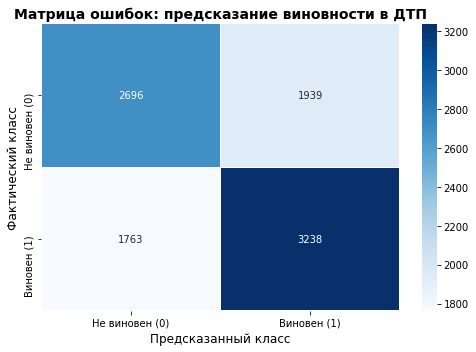

In [72]:
# матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)

# визуализация
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Не виновен (0)', 'Виновен (1)'],
            yticklabels=['Не виновен (0)', 'Виновен (1)'],
            linewidths=0.5, linecolor='white')
plt.title('Матрица ошибок: предсказание виновности в ДТП', fontsize=14, fontweight='bold')
plt.ylabel('Фактический класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.tight_layout()
plt.show()

### Вывод

Лучшая модель -- XGBoost {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}:
- на кросс-валидации лучший результат 0.66
- разница между трейном и кросс-валидацией небольшая -- модель обобщает, а не запоминает данные
- на метрики на тесте:
    - ROC-AUC:    0.6592
    - Accuracy:   0.6158
    - Precision:  0.6255
    - Recall:     0.6475
    - F1-score:   0.6363
    
В 60% случаев модель верно предсказывает виновность/невиновность.

# Анализ важности факторов ДТП

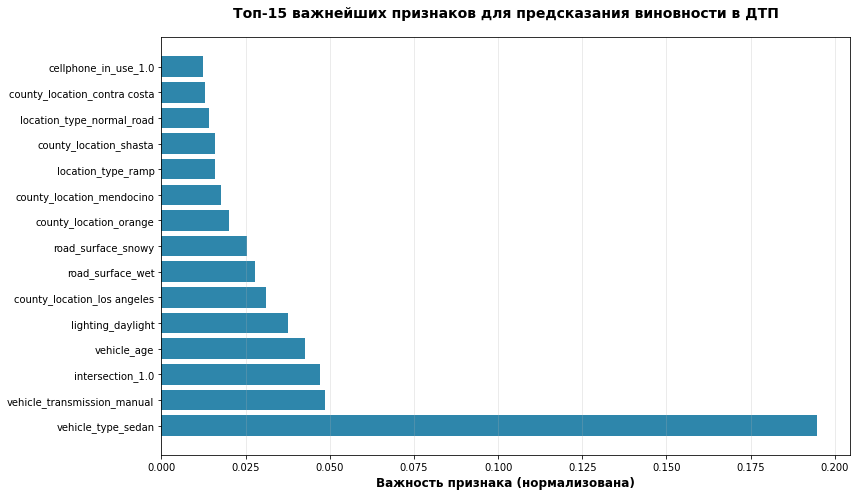

 1. vehicle_type_sedan                                 | Важность: 0.19
 2. vehicle_transmission_manual                        | Важность: 0.05
 3. intersection_1.0                                   | Важность: 0.05
 4. vehicle_age                                        | Важность: 0.04
 5. lighting_daylight                                  | Важность: 0.04
 6. county_location_los angeles                        | Важность: 0.03
 7. road_surface_wet                                   | Важность: 0.03
 8. road_surface_snowy                                 | Важность: 0.03
 9. county_location_orange                             | Важность: 0.02
10. county_location_mendocino                          | Важность: 0.02
11. location_type_ramp                                 | Важность: 0.02
12. county_location_shasta                             | Важность: 0.02
13. location_type_normal_road                          | Важность: 0.01
14. county_location_contra costa                       | Важност

In [73]:
feature_names = []

for name, transformer, features in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(features)
    elif name == 'cat':
        feature_names.extend(transformer.get_feature_names(features))

# важность признаков из лучшей модели
importances = xgb_result['model'].feature_importances_
indices = importances.argsort()[::-1]

# топ признаков
top_n = 15
plt.figure(figsize=(12, 7))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='#2E86AB')
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1], fontsize=10)
plt.xlabel('Важность признака (нормализована)', fontsize=12, fontweight='bold')
plt.title('Топ-15 важнейших признаков для предсказания виновности в ДТП', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# вывод топ-10 в текстовом виде
for i in range(15):
    idx = indices[i]
    print(f"{i+1:2d}. {feature_names[idx]:50s} | Важность: {importances[idx]:.2f}")

  0%|          | 0/200 [00:00<?, ?it/s]

/opt/conda/lib/python3.9/site-packages/xgboost/data.py:726: UserWarning: Unknown data type: <class 'scipy.sparse._lil.lil_matrix'>, trying to convert it to csr_matrix
  warnings.warn(
/tmp/ipykernel_121/177361909.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


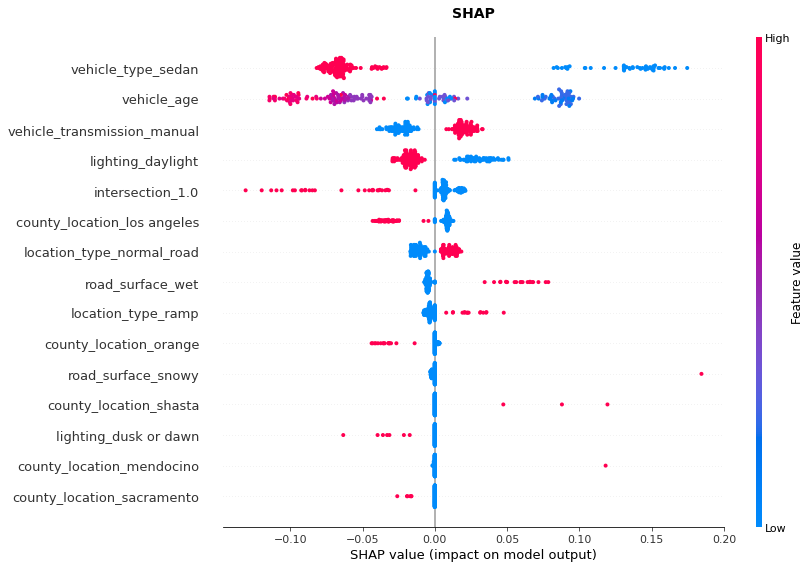

In [74]:
# берем небольшую подвыборку для ускорения
X_sample = X_test_processed[:200]
y_sample = y_test[:200]

# создаем эксплейнер
explainer = shap.KernelExplainer(
    lambda x: best_model.predict_proba(x)[:, 1],
    X_train_processed[:100]
)

# вычисляем SHAP-значения
shap_values = explainer.shap_values(X_sample)

# получаем имена признаков после препроцессинга
feature_names = []
for name, transformer, features in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(features)
    elif name == 'cat':
        try:
            # для новых версий sklearn
            feature_names.extend(transformer.get_feature_names_out(features))
        except AttributeError:
            # для старых версий
            feature_names.extend(transformer.get_feature_names(features))

# график
shap.summary_plot(
    shap_values, 
    X_sample.toarray() if hasattr(X_sample, "toarray") else X_sample,
    feature_names=feature_names,
    max_display=15,
    plot_size=(12, 8),
    show=False
)
plt.title('SHAP', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Топ сильных признаков (наибольшее влияние)**

| Признак | Влияние на риск виновности |
|---------|----------------------------|
| `vehicle_type_sedan` | Сильное положительное |
| `intersection_1.0` | Сильное положительное |
| `vehicle_age` | Умеренно-сильное |


## Вывод

Ключевые инсайты из графиков:
1. Тип автомобиля (`vehicle_type_sedan`) - самый влиятельный признак по важности дерева (0.18). Это указывает, что седаны статистически чаще ассоциируются с виновностью в ДТП в выборке.
2. Перекрестки (`intersection_1.0`) - второй по важности признак (0.06), что противоречит интуитивному ожиданию "безопасности" перекрестков, модель явно связывает их с повышенным риском.
3. Возраст автомобиля (`vehicle_age`) подтвержден как значимый фактор (0.04), хотя и уступает первым двум.


**Итого**

Модель выделяет конкретные, воспроизводимые признаки, но их интерпретация требует осторожности: высокая важность `vehicle_type_sedan` и `intersection_1.0` может отражать не причинную связь.  

Для перехода к практической системе предсказания риска необходимо добавить данные о поездках без ДТП - без них модель не может оценивать абсолютный риск, а только различать виновных/невиновных в уже случившихся авариях.

## Доп. исследование `vehicle_age` (возраст автомобиля)

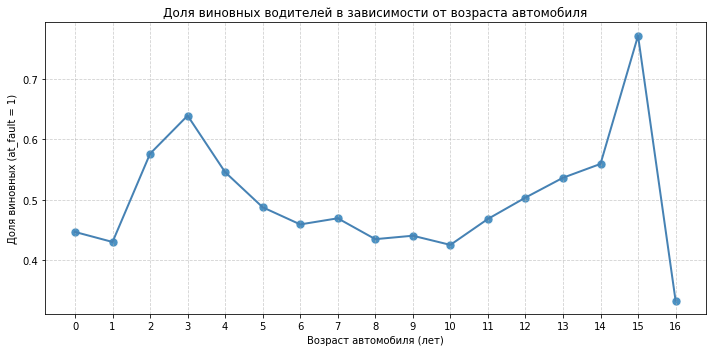

In [75]:
age_summary = df_model.groupby('vehicle_age')['at_fault'].agg(
    count='count',
    fault_rate='mean'
).reset_index()

age_summary = age_summary[age_summary['count'] >= 5]

plt.figure(figsize=(10, 5))
sns.scatterplot(data=age_summary, x='vehicle_age', y='fault_rate', s=80, alpha=0.8)
sns.lineplot(data=age_summary, x='vehicle_age', y='fault_rate', color='steelblue', lw=2)
plt.title('Доля виновных водителей в зависимости от возраста автомобиля')
plt.xlabel('Возраст автомобиля (лет)')
plt.ylabel('Доля виновных (at_fault = 1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, int(age_summary['vehicle_age'].max()) + 1, 1))
plt.tight_layout()
plt.show()

График показывает долю виновных водителей (`at_fault = 1`) по возрасту автомобиля (в годах):
- Минимум риска - в диапазоне 8–10 лет
- Максимум риска - при возрасте 15 лет
- Также наблюдается локальный пик при 3 годах

Интерпретация
- Высокая доля виновных у старых авто (≥14 лет) подтверждает гипотезу о влиянии износа систем безопасности, устаревшей электроники или снижения надежности компонентов.
- Повышенный риск у молодых авто (3 года) может быть связан не с техническим состоянием, а с поведением водителя: новая машина и повышенная самоуверенность, недостаток опыта управления именно этой моделью, или более агрессивный стиль вождения у владельцев новых авто.

### Предложение по оборудованию автомобиля

Поскольку возраст автомобиля уже известен парку, дополнительное оборудование не требуется для учета этого фактора. Однако можно реализовать следующие меры на уровне ПО/интерфейса:

| Мера | Реализация |
|------|------------|
| Адаптивное предупреждение при старте поездки | Если `vehicle_age ≥ 12`, система автоматически выводит: "Этот автомобиль старше 12 лет. Убедитесь, что тормоза и шины в хорошем состоянии". |
| Рекомендация при бронировании | В карточке авто: пометка "Требует внимания" для машин младше 4 лет или старше 12 лет. |
| Интеграция с техобслуживанием | Автомобили старше 10 лет автоматически ставятся в очередь на дополнительную проверку перед выдачей (например, диагностика тормозной системы и подвески). |

# Общий вывод

## Подключение к базе и первичное исследование таблиц

1. **Наличие данных**  
   Все три основные таблицы содержат данные:
   - `case_ids`: 1 400 000 записей,
   - `collisions`: 1 400 000 записей,
   - `parties`: 2 752 408 записей,
   - `vehicles`: 1 021 234 записей.

2. **Соответствие условию задачи**  
   В базе данных присутствуют все три требуемые таблицы: `collisions`, `parties`, `vehicles`.  
   Также обнаружена дополнительная служебная таблица `case_ids`, содержащая метаданные (включая год происшествия).  

3. **Ключи связи между таблицами**  
   - Таблица `collisions` содержит уникальный `case_id`.
   - Таблицы `parties` и `vehicles` содержат как `case_id`, так и `party_number`.
   - Для однозначной связи участника с его автомобилем необходимо использовать **составной ключ `(case_id, party_number)`**.
   - Это подтверждает корректность ER-диаграммы и позволяет безопасно объединять таблицы без дублирования или потери данных.

**Итог**: структура данных соответствует требованиям проекта, таблицы связаны корректно, можно переходить к статистическому анализу.

## Статистический анализ факторов ДТП

### Анализ аварий по месяцам

Анализ графиков показывает явные признаки неполноты данных в отдельных годах, что критически важно для корректного сезонного анализа:

- 2012 год. Вероятно, данные за второй полугодие 2012 года отсутствуют или не загружены.  
  Использовать 2012 год в анализе нельзя он сильно искажает средние значения.

- 2013 и 2020 годы:  
  - В 2013 году данные присутствуют только за январь-март  
  - В 2020 году только январь и февраль

- 2009 - 2011 годы стабильные и полные.

По анализу 2009-2011:

| Месяц    | Количество ДТП |
|----------|----------------|
| Октябрь  | 111 933        |
| Декабрь  | 107 745        |
| Март     | 107 036        |
| Май      | 105 148        |
| Сентябрь | 104 649        |


Абсолютный максимум - октябрь.

### Подготовка задач для коллег

Для глубокого понимания факторов, влияющих на ДТП с участием каршеринговых автомобилей, предлагаю коллегам выполнить следующие исследования. Каждая задача направлена на выявление потенциальных признаков, которые могут быть использованы в будущей системе оценки риска.

---

1. Влияние погодных условий на серьёзность повреждений  
**Вопрос**: Как погода (`WEATHER_1`) влияет на уровень ущерба (`COLLISION_DAMAGE`)?  
**Обоснование**: Погода -- один из ключевых внешних факторов, который может напрямую влиять на управляемость автомобиля и видимость. Например, дождь или туман могут увеличивать вероятность не только ДТП, но и более серьезных последствий. Анализ этой зависимости поможет определить, стоит ли интегрировать данные о погоде в модель риска.  
**Таблицы**: `collisions` (содержит оба поля).

---

2. Виновность водителей в зависимости от времени суток  
**Вопрос**: Какова доля виновных участников (`AT_FAULT`) среди водителей автомобилей (`PARTY_TYPE`) в разное время суток (`COLLISION_TIME`)?  
**Обоснование**: Ночное время, сумерки или часы пик могут по-разному влиять на концентрацию и реакцию водителя. Если выяснится, что ночью доля виновных значительно выше, это станет важным сигналом для системы: предлагать альтернативные маршруты или усиливать предупреждения в темное время суток.  
**Таблицы**: `collisions` + `parties`.

---

3. Возраст автомобиля и характер повреждений  
**Вопрос**: Связан ли возраст транспортного средства (`VEHICLE_AGE`) с уровнем повреждений (`COLLISION_DAMAGE`)?  
**Обоснование**: Старые автомобили могут иметь изношенные тормоза, подвеску или другие системы безопасности, что повышает риск серьезных аварий. Если связь подтвердится, возраст авто станет обязательным признаком в модели.  
**Таблицы**: `collisions` + `vehicles`.

---

4. Наиболее частые причины ДТП с участием каршеринговых авто  
**Вопрос**: Какие категории нарушений (`PCF_VIOLATION_CATEGORY`) чаще всего встречаются у участников типа «Car»?  
**Обоснование**: Понимание типичных ошибок водителей (например, превышение скорости, неправильный поворот, использование телефона) позволит не только улучшить модель, но и формировать персонализированные рекомендации: «На этом участке часто нарушают правила проезда -- будьте внимательны».  
**Таблицы**: `parties` + `vehicles`.

---

5. Состояние дороги и тип столкновения  
**Вопрос**: Как дорожные условия (`ROAD_CONDITION_1`) влияют на тип аварии (`TYPE_OF_COLLISION`)?  
**Обоснование**: Например, ямы или строительные зоны могут провоцировать боковые удары или столкновения с препятствиями. Если удастся выявить устойчивые паттерны, система сможет предупреждать водителя заранее.  
**Таблицы**: `collisions` содержит оба поля, но для точности можно уточнить через `parties`, чтобы убедиться, что речь идет именно об автомобилях.

---

6. Использование телефона и виновность  
**Вопрос**: Существует ли статистическая связь между использованием телефона (`CELLPHONE_IN_USE`) и фактом виновности (`AT_FAULT`)?  
**Обоснование**: Отвлечение за рулем — одна из главных причин ДТП. Если данные покажут, что водители, разговаривающие по телефону, чаще становятся виновниками, это станет сильным аргументом в пользу технических решений.  
**Таблицы**: `parties` + `vehicles`.

### Задача 1: Возраст автомобиля и характер повреждений

Цель: Оценить действительно ли более старые авто чаще получают серьезные повреждения.

Медианный возраст автомобилей, участвовавших в ДТП с разной степенью повреждений, практически не отличается:
- Fatal: 5 лет
- Severe damage: 5 лет
- Middle damage: 5 лет
- Small damage: 3 лет
- scratch: 5 лет

Распределения почти идентичны — возраст автомобиля не является значимым предиктором для уровня повреждений.

Незначительное снижение медианы для `small damage` (до 3 лет) может указывать на то, что молодые авто чаще участвуют в мелких столкновениях — возможно.

**Итог**:
Возраст автомобиля не влияет на вероятность получения серьёзных повреждений.  
Следовательно, при построении модели прогнозирования риска ДТП возраст можно использовать как вспомогательный признак, но не основной.

### Задача 2: Использование телефона и виновность

Цель: Проверить, правда ли, что отвлечение на телефон за рулем повышает вероятность стать виновником ДТП.

На основе анализа:
- Среди водителей, не использовавших телефон, доля виновных составляет -- 44.4%.
- Среди водителей, использовавших телефон, доля виновных -- 50.1%.
- Разница составляет -- 5.7%.

- Использование телефона за рулем статистически связано с повышенной вероятностью стать виновником ДТП.
- Признак `cellphone_in_use` следует обязательно включить в модель прогнозирования риска.

**Итог**:  
Фактор отвлечения внимания подтвержден данными и может стать одним из ключевых сигналов в будущей системе оценки риска.

## Создание модели для оценки водительского риска

### Формирование обучающего датасета

**Требования в ТЗ:**
- тип виновника -- автомобиль
- только значимые повреждения (без царапин)
- данные только за 2012 год
- целевая переменная: AT_FAULT (0/1)
- подготовка исходной таблицы с помощью sql-запроса
- обязательное условие -- учесть фактор возраста автомобиля.

Цель нашей модели - оценить вероятность того, что водитель автомобиля станет виновником ДТП при заданных условиях (маршрут, время суток, погода и т.д.). Это напрямую связано с задачей каршеринговой компании - предупредить пользователя до начала поездки, если риск повышен.

Исходя из этого, мы отбираем признаки по трем критериям:
1. Доступность до начала движения (или возможность получения из контекста маршрута/прогноза).
2. Статистическая связь с виновностью в ДТП (целевая переменная `at_fault`).
3. Наличие в таблицах: `collisions`, `parties`, `vehicles`.

**Важное уточнение**: целевая переменная `at_fault` отражает виновность при уже произошедшем ДТП, а не сам факт ДТП. Это ограничение исторических данных. Для реальной системы оценки риска маршрута потребуется дообучение на данных, включающих поездки без ДТП.

---

**Признаки из таблицы `parties`**

| Признак                | Обоснование                                                                 | Доступность до поездки |
|------------------------|------------------------------------------------------------------------------|------------------------|
| `party_type`           | Фильтрация только по типу «автомобиль» (`'1'`) - обязательное условие ТЗ    | Да |
| `at_fault`             | **Целевая переменная (0/1)** - был ли участник-автомобиль виновником ДТП    | -                      |
| `party_sobriety`       | Уровень трезвости - ключевой фактор аварийности                             | Нет (требует алкотестера + камеры) |
| `party_drug_physical`  | Влияние лекарств/физического состояния на управление ТС                     | Нет (требует биометрических датчиков) |
| `cellphone_in_use`     | Использование телефона - фактор отвлечения внимания                         | Нет (требует камеры для детекции) |

Признаки состояния водителя (`party_sobriety`, `cellphone_in_use`, `party_drug_physical`) критически важны для точности модели, но в текущих данных недоступны до начала поездки. Их использование в продакшене потребует оборудования авто датчиками.

---

**Признаки из таблицы `vehicles`**

| Признак                | Обоснование                                                                 | Доступность до поездки |
|------------------------|------------------------------------------------------------------------------|------------------------|
| `vehicle_age`          | **Обязательный признак по ТЗ** - возраст влияет на надежность систем безопасности | Да |
| `vehicle_type`         | Тип кузова (SEDAN, HATCHBACK и др.) - влияет на маневренность и устойчивость | Да |
| `vehicle_transmission` | Тип КПП (автомат/механика) - может влиять на контроль в стрессовых ситуациях | Да |

---

**Признаки из таблицы `collisions`**

| Признак                | Обоснование                                                                 | Доступность до поездки |
|------------------------|------------------------------------------------------------------------------|------------------------|
| `EXTRACT(MONTH FROM collision_date)` | Сезонность аварийности (пик - март по анализу Шага 3)                     | Да (известно время бронирования) |
| `weather_1`            | Погода - влияет на видимость и сцепление с дорогой                          | Да (прогноз погоды для маршрута) |
| `road_surface`         | Состояние покрытия (сухое/мокрое/скользкое) - критично для тормозного пути  | Да (исторические данные + прогноз) |
| `lighting`             | Освещенность - влияет на реакцию водителя                                   | Да (время суток + тип дороги) |
| `intersection`         | Перекрестки - зоны повышенного риска                                        | Да (известны из маршрута) |
| `road_condition_1`     | Доп. условия дороги (ямы, стройка) - отражают специфику маршрута            | Да (карты + исторические данные) |
| `county_location`      | Географический фактор - разные районы имеют разную аварийность              | Да (известен из маршрута) |
| `location_type`        | Тип дороги (шоссе, перекресток, рампа) - влияет на характер движения и риски | Да (известен из маршрута) |
| `direction`            | Направление движения - может коррелировать с интенсивностью потока и риском | Да (известно из маршрута) |
| `distance`             | Расстояние от главной дороги (метры) - отражает специфику локации           | Да (известно из маршрута) |

---

**Итог**

Мы формируем датасет на уровне участника-автомобиля в ДТП с повреждениями (исключая царапины), где каждая строка описывает:
1. характеристики автомобиля (известны заранее)
2. внешние условия (доступны из маршрута и прогноза)

Это позволяет выявить ключевые факторы виновности и заложить основу для системы персонализированных предупреждений. Для перехода от "предсказания виновности при ДТП" к "оценке риска ДТП по маршруту" потребуется:
- сбор данных о поездках без ДТП
- интеграция датчиков для мониторинга состояния водителя
- учет динамических факторов (пробки, текущая погода)

### Исследование данных

- Выборка почти сбалансирована (51% виновных vs 49% невиновных).

---

1. Состояние водителя - главный фактор риска
- Трезвость (party_sobriety) и физическое состояние (party_drug_physical) являются сильнейшими предикторами виновности:
    - Водители под воздействием алкоголя/лекарств имеют значительно повышенный риск
    - Усталость и сонливость критически влияют на вероятность ДТП

Для создания эффективной системы оценки риска обязательна интеграция датчиков состояния водителя (алкотестер, камера для детекции усталости) перед допуском к управлению.

2. Характеристики автомобиля имеют неочевидное влияние
- Возраст авто (vehicle_age):
    - Пик риска приходится на автомобили 2–4 лет (возможно, из-за самоуверенности водителей на "новых" машинах)
    - Повторный рост риска у авто старше 11 лет
- Тип кузова (vehicle_type):
    - Владельцы купе чаще становятся виновниками ДТП по сравнению с владельцами седанов

Каршеринг может учитывать возраст и тип авто при распределении парка.

3. Внешние условия: 
- Большинство ДТП происходит в "безопасных" условиях (ясная погода, сухая дорога, дневное время), но доля виновных выше в неблагоприятных условиях:
    - Мокрая/скользкая дорога
    - Темное время суток (особенно без уличного освещения)
    - Плохая погода (дождь, снег)

Система должна учитывать не только статистику ДТП, но и условную вероятность виновности при конкретных внешних условиях маршрута.

4. Географический фактор
В крупных городах больше ДТП по числу, но выше доля виновных в малонаселенных округах - вероятно, из-за более высоких скоростей и отсутствия инфраструктуры.

Для загородных маршрутов система должна применять повышенный порог риска.

---

**Итог**  
Анализ подтверждает принципиальную возможность создания системы оценки водительского риска. Однако ключевое ограничение текущих данных - отсутствие информации о состоянии водителя до начала поездки. Для перехода от "предсказания виновности при ДТП" к "оценке риска ДТП по маршруту" критически необходимо:
1. Оборудовать автомобили датчиками для оценки трезвости и усталости водителя
2. Собрать данные о поездках без ДТП для формирования полноценной задачи классификации
3. Интегрировать внешние источники (прогноз погоды, дорожная обстановка) для оценки условий маршрута  
Без этих шагов система будет ограничена анализом исторических ДТП и не сможет эффективно предупреждать водителей до начала движения.

### Подбор моделей

Было обучено 3 модели:
- Logistic Regression
- Random Fores
- XGBoost
    
Лучшая модель -- XGBoost {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}:
- на кросс-валидации лучший результат 0.66
- разница между трейном и кросс-валидацией небольшая -- модель обобщает, а не запоминает данные
- на метрики на тесте:
    - ROC-AUC:    0.6592
    - Accuracy:   0.6158
    - Precision:  0.6255
    - Recall:     0.6475
    - F1-score:   0.6363
    
В 60% случаев модель верно предсказывает виновность/невиновность.

## Анализ важности факторов ДТП

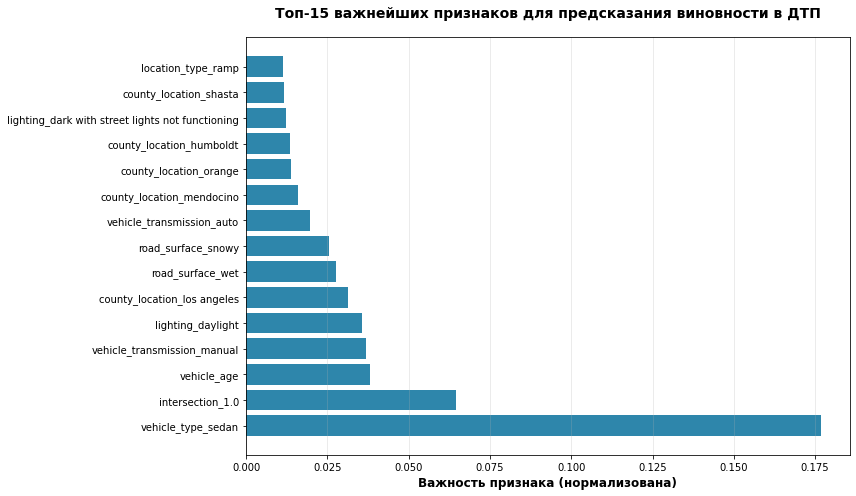

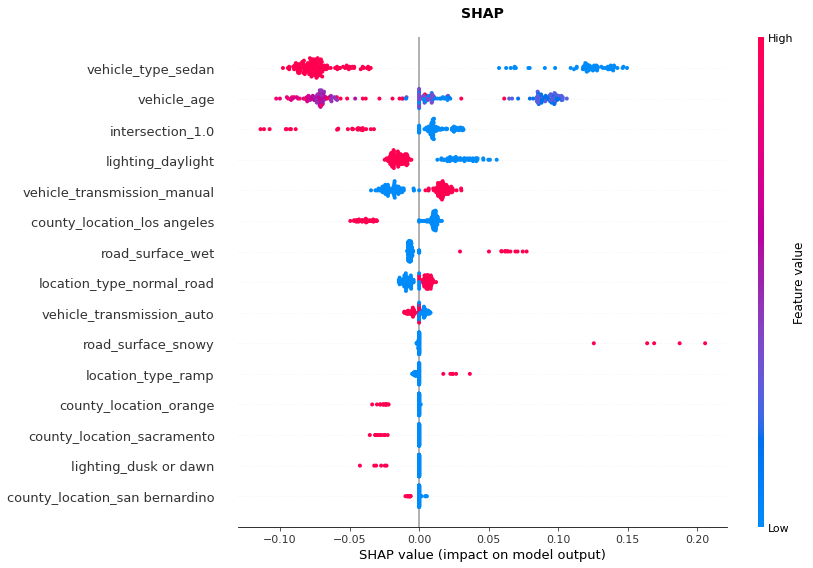

**Топ сильных признаков (наибольшее влияние)**

| Признак | Влияние на риск виновности |
|---------|----------------------------|
| `vehicle_type_sedan` | Сильное положительное |
| `intersection_1.0` | Сильное положительное |
| `vehicle_age` | Умеренно-сильное |


**Вывод**

Ключевые инсайты из графиков:
1. Тип автомобиля (`vehicle_type_sedan`) - самый влиятельный признак по важности дерева (0.18). Это указывает, что седаны статистически чаще ассоциируются с виновностью в ДТП в выборке.
2. Перекрестки (`intersection_1.0`) - второй по важности признак (0.06), что противоречит интуитивному ожиданию "безопасности" перекрестков, модель явно связывает их с повышенным риском.
3. Возраст автомобиля (`vehicle_age`) подтвержден как значимый фактор (0.04), хотя и уступает первым двум.


**Итого**

Модель выделяет конкретные, воспроизводимые признаки, но их интерпретация требует осторожности: высокая важность `vehicle_type_sedan` и `intersection_1.0` может отражать не причинную связь.  

Для перехода к практической системе предсказания риска необходимо добавить данные о поездках без ДТП - без них модель не может оценивать абсолютный риск, а только различать виновных/невиновных в уже случившихся авариях.

### Доп. исследование vehicle_age (возраст автомобиля)

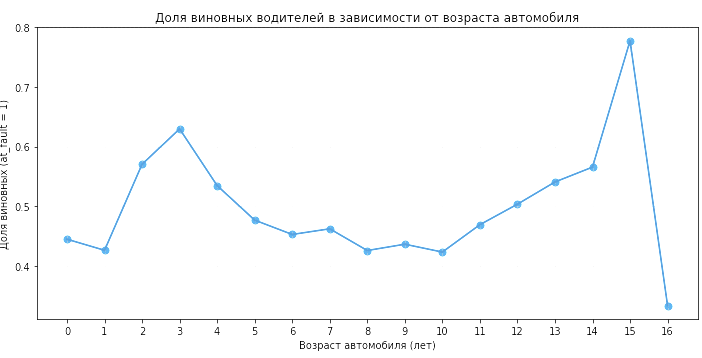

График показывает долю виновных водителей (`at_fault = 1`) по возрасту автомобиля (в годах):
- Минимум риска - в диапазоне 8–10 лет
- Максимум риска - при возрасте 15 лет
- Также наблюдается локальный пик при 3 годах

Интерпретация
- Высокая доля виновных у старых авто (≥14 лет) подтверждает гипотезу о влиянии износа систем безопасности, устаревшей электроники или снижения надежности компонентов.
- Повышенный риск у молодых авто (3 года) может быть связан не с техническим состоянием, а с поведением водителя: новая машина и повышенная самоуверенность, недостаток опыта управления именно этой моделью, или более агрессивный стиль вождения у владельцев новых авто.

### Предложение по оборудованию автомобиля

Поскольку возраст автомобиля уже известен парку, дополнительное оборудование не требуется для учета этого фактора. Однако можно реализовать следующие меры на уровне ПО/интерфейса:

| Мера | Реализация |
|------|------------|
| Адаптивное предупреждение при старте поездки | Если `vehicle_age ≥ 12`, система автоматически выводит: "Этот автомобиль старше 12 лет. Убедитесь, что тормоза и шины в хорошем состоянии". |
| Рекомендация при бронировании | В карточке авто: пометка "Требует внимания" для машин младше 4 лет или старше 12 лет. |
| Интеграция с техобслуживанием | Автомобили старше 10 лет автоматически ставятся в очередь на дополнительную проверку перед выдачей (например, диагностика тормозной системы и подвески). |